# Customer Churn Prediction

**Dataset:** IBM Telco Customer Churn (`data/TelcoCustomerChurn.csv`)
**Target:** `Churn` (Yes/No)

This notebook is the Day 1 deliverable: business framing, data understanding, EDA, feature engineering, Decision Tree modeling, evaluation, and interpretation, followed by saving the trained pipeline for the Day 2 API.

Structure follows the assignment brief section by section. Only the Markdown structure is populated so far — implementation will be added incrementally.

## 1. Business Problem

**Customer churn** refers to customers discontinuing their relationship with the company — in this context, cancelling their telecom service (phone, internet, or both).

Churn is costly for a telecom company: acquiring a new customer is significantly more expensive than retaining an existing one, and lost customers also mean lost recurring monthly revenue. If the company can identify **which customers are likely to churn *before* they leave**, the retention team can proactively intervene (e.g. targeted offers, service improvements, contract incentives) rather than reacting after the customer has already left.

**Our machine learning objective:** build a classification model that, given a customer's account and service attributes (contract type, tenure, billing method, services subscribed, charges, etc.), predicts whether that customer is likely to churn. This allows the retention team to rank/flag at-risk customers and prioritize outreach.

**Target variable:** `Churn` — a binary label with values `Yes` (the customer left) and `No` (the customer stayed).

**Why this section is required:** framing the business objective up front keeps every later modeling and evaluation choice (e.g. precision vs. recall trade-off) anchored to the actual business goal rather than pure accuracy.

## 2. Dataset Overview

Load `data/TelcoCustomerChurn.csv` and cross-reference it against `data/TelcoCustomerChurn - Data Dictionary.csv` to understand what each column represents, its expected values, and its role (identifier, feature, or target).

**Why this section is required:** the assignment asks us to "load and investigate the dataset" — a quick overview of shape, columns, and dictionary meaning is the necessary first step before any deeper checks.

In [1]:
import pandas as pd
from pathlib import Path

# Resolve the project root robustly, regardless of the working directory the kernel starts in
# (normally VS Code/Jupyter sets it to this notebook's folder, "notebook/", but this also works
# if the notebook is ever executed from the project root itself). We walk upward from the
# current working directory until we find the folder that contains both "data/" and "notebook/"
# - the two directories that anchor this project's fixed structure. No absolute paths needed.
def find_project_root(start: Path) -> Path:
    for directory in [start, *start.parents]:
        if (directory / "data").is_dir() and (directory / "notebook").is_dir():
            return directory
    raise FileNotFoundError(
        f"Could not locate the project root (a folder containing both 'data/' and 'notebook/') from {start}"
    )

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "model"

df = pd.read_csv(DATA_DIR / "TelcoCustomerChurn.csv")
data_dict = pd.read_csv(DATA_DIR / "TelcoCustomerChurn - Data Dictionary.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape (rows, columns): (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
data_dict

,Column,Data Type,Description,Example / Values
0,customerID,Categorical / ID,Unique identifier for each customer,7590-VHVEG
1,gender,Categorical,Gender of the customer,"Male, Female"
2,SeniorCitizen,Numerical / Binary,Indicates whether the customer is a senior cit...,"0, 1"
3,Partner,Categorical,Whether the customer has a partner,"Yes, No"
4,Dependents,Categorical,Whether the customer has dependents,"Yes, No"
5,tenure,Numerical,Number of months the customer has been with th...,"1, 24, 72"
6,PhoneService,Categorical,Whether the customer has phone service,"Yes, No"
7,MultipleLines,Categorical,Whether the customer has multiple phone lines,"Yes, No, No phone service"
8,InternetService,Categorical,Type of internet service subscribed to,"DSL, Fiber optic, No"
9,OnlineSecurity,Categorical,Whether the customer has online security service,"Yes, No, No internet service"


**Data dictionary walkthrough — important columns:**

- `customerID`: unique identifier for each customer. Not predictive — will be excluded from modeling later.
- `tenure`: number of months the customer has been with the company. A core driver of churn (newer customers tend to churn more).
- `Contract`: Month-to-month, One year, or Two year. Strongly related to churn — month-to-month customers can leave at any time with no penalty.
- `MonthlyCharges` / `TotalCharges`: billing amounts. `TotalCharges` is listed as numerical in the dictionary but will need a type check (Section 4), since it's often stored as text in this dataset.
- Service columns (`PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`): describe which services the customer subscribes to; several use a `"No internet/phone service"` category that is really just a dependent form of "No".
- `PaperlessBilling` / `PaymentMethod`: billing behavior; payment method (especially "Electronic check") is commonly associated with higher churn in this dataset.
- `gender`, `SeniorCitizen`, `Partner`, `Dependents`: demographic attributes.
- `Churn`: the **target variable** — `Yes` if the customer left, `No` if they stayed.

## 3. Data Understanding

Inspect data types and structure (`.info()`, `.dtypes`), identify numerical vs. categorical features, and analyze the target variable (`Churn`) distribution/class balance.

**Why this section is required:** the assignment explicitly calls for "data type and structure checks", "numerical and categorical feature identification", and "target-variable analysis" — this informs encoding choices and whether class imbalance needs to be handled later.

In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
# Basic descriptive statistics
# include="all" so we see counts/uniques/top/freq for categorical columns too,
# alongside mean/std/min/max for the numerical ones.
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**What each inspection tells us:**

- `df.shape` / `df.columns`: 7,043 customer records across 21 columns — confirms the dataset size and that all expected fields from the data dictionary are present.
- `df.head()`: gives a first look at real values (e.g. how `Yes`/`No` and service categories are represented as text, not already encoded).
- `df.dtypes`: shows pandas inferred most columns as `object` (text/categorical) and a few as `int64`/`float64`. Notably, **`TotalCharges` is `object`, not numeric** — this is a red flag we'll investigate and fix in Section 4/5, since it should logically be numerical.
- `df.describe(include="all")`: for numerical columns (`tenure`, `MonthlyCharges`, `SeniorCitizen`) it gives mean/std/min/max, hinting at ranges and possible skew; for categorical columns it gives count of unique values, the most frequent category (`top`), and its frequency (`freq`) — useful for spotting dominant categories and rare classes.

**Numerical columns:** `tenure`, `MonthlyCharges`, `TotalCharges` (once converted from text), `SeniorCitizen` (technically binary/encoded as 0/1, so it behaves like a categorical flag even though it's numeric).

**Categorical columns:** `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`.

**Target column:** `Churn` (`Yes` / `No`).

**Observations to document going into later sections:**
- `TotalCharges` is stored as `object` and will need to be coerced to numeric — likely because some rows contain blank/whitespace values (typically customers with `tenure = 0`), which will surface as missing values once converted.
- `customerID` is a unique identifier with no predictive value and should be excluded from modeling.
- Several service columns use a `"No internet service"` / `"No phone service"` category that is redundant with another column (`InternetService`/`PhoneService`) — a candidate for simplification during cleaning/encoding.
- `SeniorCitizen` is already numeric (0/1) while conceptually categorical — worth treating consistently with the other binary categorical flags during encoding.
- Class balance of `Churn` hasn't been checked yet — that's the next step (target-variable analysis) before we finalize any modeling strategy.

## 4. Data Quality Analysis

Check for missing values (including disguised blanks, e.g. `TotalCharges`), duplicate rows/customer IDs, and any inconsistent or invalid category values.

**Why this section is required:** the assignment calls for explicit "missing-value analysis" and "duplicate analysis" as separate, documented steps before any cleaning is applied.

In [6]:
# 1. Missing values (standard NaN check)
df.isnull().sum().sort_values(ascending=False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

**Finding:** `df.isnull().sum()` reports **zero** missing values across all 21 columns.

**Why this is misleading:** `TotalCharges` was loaded as an `object`/string column (seen in Section 3), not numeric. If it contains blank or whitespace-only strings instead of proper `NaN`, pandas' `isnull()` won't detect them — they look like valid (non-null) strings. This is investigated explicitly below.

**Proposed treatment:** don't trust this check in isolation for `TotalCharges`; re-run missing-value detection *after* converting it to numeric (see the `TotalCharges` investigation below).

In [7]:
# 2. Duplicate rows
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())

Fully duplicated rows: 0
Duplicate customerIDs: 0


**Finding:** 0 fully duplicated rows and 0 duplicate `customerID` values — each row represents a unique customer.

**Why this matters:** duplicate rows would double-count some customers, subtly biasing the churn rate and giving the model repeated identical examples (effectively over-weighting them). Duplicate `customerID`s with different attribute values would indicate a data integrity problem (conflicting records for the same customer).

**Proposed treatment:** none needed — no duplicates found. Keeping this check is still valuable for future data refreshes: if duplicates appear, the (documented, not-yet-applied) rule would be to drop exact duplicate rows (`df.drop_duplicates()`) and manually investigate any duplicate `customerID` with differing values before deciding which record is authoritative.

In [8]:
# 3. Data types — focused investigation of TotalCharges
print(df["TotalCharges"].apply(type).value_counts())

blank_mask = df["TotalCharges"].str.strip() == ""
print("\nBlank/whitespace TotalCharges rows:", blank_mask.sum())
df.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

TotalCharges
<class 'str'>    7043
Name: count, dtype: int64

Blank/whitespace TotalCharges rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [9]:
# Confirm what happens if we coerce TotalCharges to numeric
coerced_total_charges = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows that fail numeric conversion:", coerced_total_charges.isna().sum())

Rows that fail numeric conversion: 11


**Finding:** `TotalCharges` is stored as a **string**, and **11 rows** contain a blank/whitespace value instead of a number. All 11 of these rows have **`tenure = 0`** (brand-new customers) and **`Churn = No`** — consistent with customers who just signed up and haven't been billed yet.

**Why this is an issue:**
- A numeric column stored as text can't be used in arithmetic, aggregation, or fed directly into a scikit-learn numeric feature — it would either error out or (worse) be silently treated as categorical.
- These 11 blanks are true missing values that a naive `isnull()` check (Finding 1 above) did not catch, because pandas saw non-empty-looking whitespace strings, not `NaN`.

**Proposed treatment (to apply in Section 5, not yet applied here):**
1. Convert `TotalCharges` to numeric with `pd.to_numeric(df["TotalCharges"], errors="coerce")`, which turns the 11 blanks into real `NaN`.
2. Impute those 11 `NaN`s with **0**, not the column mean/median — because these are customers with `tenure = 0` who logically have not accumulated any charges yet. Using the mean would fabricate a billing history that never happened; dropping the rows would needlessly lose 11 valid customer records (and their `Churn = No` label).

In [10]:
# 4. Unique values in important categorical columns
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "Churn",
]

for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique())}")

gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn: ['No', 'Yes']


**Finding:** all categorical columns contain clean, consistent values — no typos, casing issues, or stray categories. `gender` is `{Female, Male}`, most service flags are `{Yes, No}`, and `Contract`/`PaymentMethod` have the expected small set of labels.

**Issue found:** 7 columns (`MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) contain a third category — `"No phone service"` / `"No internet service"` — that is **fully redundant** with `PhoneService` / `InternetService`. E.g. `MultipleLines = "No phone service"` only ever occurs when `PhoneService = "No"`; it carries no extra information beyond what those two columns already encode.

**Why this matters:** leaving this as-is isn't incorrect, but it inflates the categorical feature space after one-hot encoding (an extra column per feature) and could make the Decision Tree split on a category that is deterministically implied by another feature, muddying interpretation.

**Proposed treatment (Section 5/9, not applied yet):** collapse `"No phone service"` → `"No"` in `MultipleLines`, and `"No internet service"` → `"No"` in the six internet-dependent columns. The information about *whether* the customer has phone/internet service is still fully preserved by `PhoneService`/`InternetService`, so no information is lost.

In [11]:
# 5. Suspicious or inconsistent values
print("SeniorCitizen unique values:", sorted(df["SeniorCitizen"].unique()))
print("tenure range:", df["tenure"].min(), "-", df["tenure"].max())
print("MonthlyCharges range:", df["MonthlyCharges"].min(), "-", df["MonthlyCharges"].max())
print("Customers with tenure == 0:", (df["tenure"] == 0).sum())
print("Negative tenure rows:", (df["tenure"] < 0).sum())
print("Negative MonthlyCharges rows:", (df["MonthlyCharges"] < 0).sum())

SeniorCitizen unique values: [np.int64(0), np.int64(1)]
tenure range: 0 - 72
MonthlyCharges range: 18.25 - 118.75
Customers with tenure == 0: 11
Negative tenure rows: 0
Negative MonthlyCharges rows: 0


**Finding:** `SeniorCitizen` is properly binary (`0`/`1`); `tenure` ranges `0`–`72` months with no negative values; `MonthlyCharges` ranges `$18.25`–`$118.75`, also with no negative values. Exactly **11 customers have `tenure == 0`** — the same 11 rows identified with blank `TotalCharges` above, which cross-validates that hypothesis (new customers, no billing history yet).

**Why this matters:** no impossible or corrupted values were found (e.g. negative tenure/charges, out-of-range binary flags), so there's no evidence of data entry errors beyond the `TotalCharges` issue already documented.

**Proposed treatment:** no row removal needed. The 11 `tenure == 0` customers are valid, legitimate records and should be **kept** — they will simply have `TotalCharges` imputed to `0` (Section 5) rather than being dropped, since removing them would discard real churn-label data for no good reason.

In [12]:
# 6. Target variable distribution
print(df["Churn"].value_counts())
print()
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Finding:** `Churn = No` for 5,174 customers (73.46%) and `Churn = Yes` for 1,869 customers (26.54%) — a **moderate class imbalance** (roughly 3:1).

**Why this is an issue:** a classifier trained naively on this ratio can achieve high *accuracy* just by leaning toward predicting "No churn" for almost everyone, while missing a large share of the actual churners (low recall). Given our Section 1 business objective — catching customers who are about to churn — this imbalance directly threatens the metric that matters most operationally.

**Proposed treatment (deferred to later sections, not applied here):**
- Use **stratified** train/test splitting (`stratify=df["Churn"]`) in Section 8 so both splits preserve the ~73/27 ratio.
- Do not oversample/undersample at this stage; instead address the imbalance at the model level in Section 10 (e.g. `class_weight="balanced"` in `DecisionTreeClassifier`) and explicitly discuss the precision/recall trade-off in Section 11, rather than resampling the raw data.

---

### Summary of Section 4 findings and deferred decisions

| # | Check | Finding | Treatment (applied later, in Section 5/8/9/10) |
|---|---|---|---|
| 1 | Missing values (`isnull`) | 0 detected, but misleading for `TotalCharges` | Recheck after numeric conversion |
| 2 | Duplicate rows | 0 duplicate rows/IDs | None needed |
| 3 | `TotalCharges` dtype | Stored as string; 11 blank rows (`tenure=0`) | Convert to numeric, impute blanks with 0 |
| 4 | Categorical uniques | Clean values; redundant `"No ... service"` category in 7 columns | Collapse to `"No"` during encoding |
| 5 | Suspicious values | No negative/out-of-range values; 11 `tenure=0` rows confirmed | Keep rows, no removal |
| 6 | Target distribution | 73.46% No / 26.54% Yes (moderate imbalance) | Stratified split; consider `class_weight` later |

No rows have been dropped or values modified in this notebook yet — all treatments above will be implemented explicitly in **Section 5: Data Cleaning and Preparation**.

## 5. Data Cleaning and Preparation

Fix identified data quality issues (e.g. coerce `TotalCharges` to numeric, handle resulting missing values, drop non-predictive identifiers like `customerID`).

**Why this section is required:** the assignment requires "data cleaning and preprocessing" as its own step, and stresses avoiding data leakage — cleaning decisions made here must be things we can also apply consistently to new/unseen data later.

In [13]:
# --- Cleaning TotalCharges: BEFORE conversion ---
print("dtype BEFORE conversion:", df["TotalCharges"].dtype)
print("Sample raw values:", df["TotalCharges"].head(3).tolist())

dtype BEFORE conversion: str
Sample raw values: ['29.85', '1889.5', '108.15']


In [14]:
# --- Convert TotalCharges to numeric safely ---
# errors="coerce" turns any value that can't be parsed as a number into NaN
# instead of raising an exception, so we can inspect what failed.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("dtype AFTER conversion:", df["TotalCharges"].dtype)

dtype AFTER conversion: float64


In [15]:
# --- Identify values that became missing after conversion ---
missing_mask = df["TotalCharges"].isna()
print("Missing values after conversion:", missing_mask.sum())

df.loc[missing_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

Missing values after conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,NaN,Two year,No
753,3115-CZMZD,0,20.25,NaN,Two year,No
936,5709-LVOEQ,0,80.85,NaN,Two year,No
1082,4367-NUYAO,0,25.75,NaN,Two year,No
1340,1371-DWPAZ,0,56.05,NaN,Two year,No
3331,7644-OMVMY,0,19.85,NaN,Two year,No
3826,3213-VVOLG,0,25.35,NaN,Two year,No
4380,2520-SGTTA,0,20.00,NaN,Two year,No
5218,2923-ARZLG,0,19.70,NaN,One year,No
6670,4075-WKNIU,0,73.35,NaN,Two year,No


In [16]:
# --- Investigate why these values became missing ---
print("tenure values among missing rows:", df.loc[missing_mask, "tenure"].unique())
print("Contract types among missing rows:")
print(df.loc[missing_mask, "Contract"].value_counts())

tenure values among missing rows: [0]
Contract types among missing rows:
Contract
Two year    10
One year     1
Name: count, dtype: int64


**Investigation result:** all 11 rows that became `NaN` have **`tenure = 0`** — i.e. brand-new customers who signed up but haven't completed a full billing cycle yet (10 on a `Two year` contract, 1 on `One year`; none are `Month-to-month`). This explains the blank string in the source data: there is genuinely no "total charged" amount yet, since no invoice has been issued. All 11 have `Churn = No`, consistent with customers who are still within their very first (uncompleted) billing period.

This is **not random/unexplained missingness** — it's a structural consequence of `tenure = 0`, so we can handle it with a domain-driven rule rather than a generic statistical imputation.

In [17]:
# --- Handle the missing values ---
# Impute with 0: a tenure=0 customer has, by definition, not been billed yet,
# so "0 total charged so far" is the factually correct value, not an estimate.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing values remaining:", df["TotalCharges"].isna().sum())
print("dtype:", df["TotalCharges"].dtype)
df.loc[df["tenure"] == 0, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Missing values remaining: 0
dtype: float64


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,0.0
753,3115-CZMZD,0,20.25,0.0
936,5709-LVOEQ,0,80.85,0.0
1082,4367-NUYAO,0,25.75,0.0
1340,1371-DWPAZ,0,56.05,0.0
3331,7644-OMVMY,0,19.85,0.0
3826,3213-VVOLG,0,25.35,0.0
4380,2520-SGTTA,0,20.00,0.0
5218,2923-ARZLG,0,19.70,0.0
6670,4075-WKNIU,0,73.35,0.0


**Why imputing with 0 is appropriate here:**
- The missingness isn't random — it's fully explained by `tenure = 0`. For those customers, "total amount charged so far" is genuinely zero; it isn't an unknown value we're estimating, it's a known fact we're recording correctly.
- Using the column mean/median instead would fabricate a billing history that never happened, and would bias `TotalCharges` upward for exactly the customers who have paid the least.
- Dropping the 11 rows would discard real, valid customer records — including their `Churn = No` label — solely because of a data-formatting artifact, which is worse than necessary given we can explain and correctly fill the value.

**Does this introduce data leakage?**

No. Data leakage would occur if the fill value were **derived from statistics computed over data the model shouldn't have access to at prediction time** (e.g. the training set's mean, or worse, a mean computed over the combined train+test data before splitting). Here, the imputation value (`0`) is a **fixed, domain-derived constant** — it comes from the business logic "no billing cycle completed yet," not from any statistic of `TotalCharges` itself. It doesn't depend on the target variable, on the train/test split, or on any other row in the dataset.

Because of this, it's safe to apply this specific rule to the full dataset *before* the train/test split (Section 8) — unlike, say, mean/median imputation or scaling, which must always be *fit* on the training set only and then *applied* to the test set, to avoid leaking test-set statistics into training. That distinction will be made explicit again in Section 9 (Data Preprocessing), where any fitted transformers are fit strictly on the training split.

### Cleaning categorical columns

Section 4 already confirmed the *set* of category values is clean (no obviously invalid labels). Here we go one level deeper and check for issues that `unique()` alone can hide: leading/trailing whitespace and inconsistent casing (e.g. `" Yes"` or `"yes"` silently creating a duplicate category), plus whether any numeric-looking column should really be treated as categorical.

In [18]:
# --- Check for leading/trailing whitespace in categorical (string) columns ---
object_cols = df.select_dtypes(include="str").columns.tolist()
print("Categorical (string) columns:", object_cols)

whitespace_issues = {
    col: (df[col] != df[col].str.strip()).sum()
    for col in object_cols
    if (df[col] != df[col].str.strip()).sum() > 0
}
print("\nColumns with whitespace issues:", whitespace_issues if whitespace_issues else "None found")

Categorical (string) columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Columns with whitespace issues: None found


In [19]:
# --- Check for inconsistent casing (e.g. "Yes" vs "yes" treated as different categories) ---
case_issues = {
    col: (df[col].nunique(), df[col].str.lower().nunique())
    for col in object_cols
    if col != "customerID" and df[col].nunique() != df[col].str.lower().nunique()
}
print("Columns with case-inconsistent categories (actual, lowercased):",
      case_issues if case_issues else "None found")

Columns with case-inconsistent categories (actual, lowercased): None found


**Finding:** no whitespace issues and no case-inconsistent duplicate categories in any of the 17 string columns.

**Decision:** no trimming or case-normalization cleaning is applied, because there is nothing to fix — this dataset's categorical values are already consistently formatted. (Documenting a clean check is still useful: it confirms the assumption rather than leaving it unverified, and the same checks should be re-run if new/unseen data is ever ingested through this same pipeline.)

**Values that should be treated as categories:** `SeniorCitizen` is stored as `int64` (`0`/`1`), but conceptually it is a binary flag exactly like `Partner`, `Dependents`, or `PhoneService` — not a continuous quantity. Leaving it as a raw integer risks it being handled inconsistently later (e.g. accidentally scaled as if it were numeric, or excluded from a categorical-encoding step). We standardize its representation to match the other Yes/No flags.

In [20]:
# --- Re-represent SeniorCitizen as a Yes/No category, consistent with the other binary flags ---
print("SeniorCitizen dtype BEFORE:", df["SeniorCitizen"].dtype)
print("Unique values BEFORE:", sorted(df["SeniorCitizen"].unique()))

df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

print("\nSeniorCitizen dtype AFTER:", df["SeniorCitizen"].dtype)
print(df["SeniorCitizen"].value_counts())

SeniorCitizen dtype BEFORE: int64
Unique values BEFORE: [np.int64(0), np.int64(1)]

SeniorCitizen dtype AFTER: str
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [21]:
# --- Resulting data types after all Section 5 cleaning ---
df.dtypes

customerID              str
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [22]:
# --- Important value distributions after cleaning ---
for col in ["SeniorCitizen", "Contract", "InternetService", "PaymentMethod", "Churn"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(3))
    print()

--- SeniorCitizen ---
SeniorCitizen
No     0.838
Yes    0.162
Name: proportion, dtype: float64

--- Contract ---
Contract
Month-to-month    0.550
Two year          0.241
One year          0.209
Name: proportion, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.440
DSL            0.344
No             0.217
Name: proportion, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             0.336
Mailed check                 0.229
Bank transfer (automatic)    0.219
Credit card (automatic)      0.216
Name: proportion, dtype: float64

--- Churn ---
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64



### Section 5 summary — cleaning decisions and rationale

| Decision | Applied? | Why |
|---|---|---|
| Convert `TotalCharges` to numeric, impute the 11 blanks with `0` | Yes | Stored as text; blanks correspond to `tenure=0` customers with no billing history yet — `0` is factually correct, not estimated |
| Trim whitespace in categorical columns | Not needed | Checked explicitly — no whitespace found in any of the 17 string columns |
| Normalize inconsistent casing | Not needed | Checked explicitly — no case-duplicated categories found |
| Re-represent `SeniorCitizen` as `"No"`/`"Yes"` | Yes | It's conceptually a binary flag like `Partner`/`Dependents`, just stored as `0`/`1`; aligning representation avoids inconsistent handling later, without changing any information |
| Collapse `"No internet/phone service"` into `"No"` | **Not yet** | This is a redundant-category simplification tied to *encoding* strategy, not a data-quality fix — deferred to Section 9 (Data Preprocessing) where the modeling pipeline is defined |
| Drop `customerID` | **Not yet** | Not a data-quality issue (it's valid, unique, and correct) — it will simply be excluded from the model's feature set during preprocessing (Section 9), not deleted from the dataframe |

**Guiding principle:** every change above is justified by an explicit, demonstrated issue (wrong dtype, inconsistent representation) — no rows or categories were removed, and no cleaning was applied speculatively. `df` now has correct dtypes (`TotalCharges`/`MonthlyCharges` as `float64`, `tenure` as `int64`, all others as consistent string categories) and is ready for EDA.

## 6. Exploratory Data Analysis

At least 5 visualizations covering: churn distribution, customer/service characteristics, churn against important customer attributes, and numerical variable distributions/relationships. Each chart will include a short business insight.

**Why this section is required:** the assignment explicitly requires EDA "to understand customer behaviour and factors associated with churn", with a minimum of 5 meaningful visualizations and business commentary per chart.

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- Target variable analysis: counts and percentages ---
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Counts:")
print(churn_counts)
print("\nPercentages:")
print(churn_pct.round(2))

Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


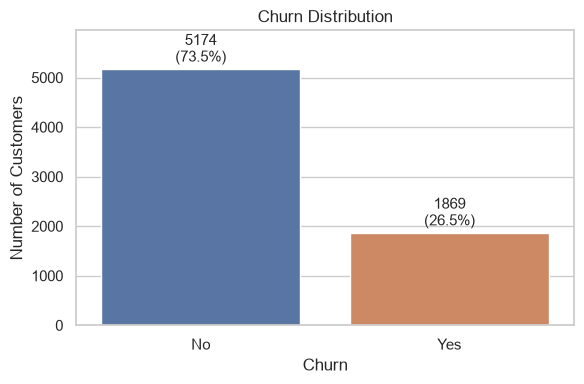

In [24]:
# --- Visualization: Churn distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
order = ["No", "Yes"]
sns.countplot(data=df, x="Churn", order=order, hue="Churn", palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)

total = len(df)
for i, label in enumerate(order):
    count = churn_counts[label]
    pct = 100 * count / total
    ax.text(i, count + 60, f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11)

ax.set_title("Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, churn_counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Is the target balanced?**
No. Of 7,043 customers, 5,174 (73.46%) did not churn and 1,869 (26.54%) did — roughly a 3:1 ratio. This is a **moderate class imbalance**: not extreme (e.g. fraud detection at 99:1), but skewed enough that it cannot be ignored.

**Why class distribution matters for a classification problem:**
- Many models implicitly optimize for overall accuracy, which biases them toward the majority class when classes are imbalanced — the model can achieve a deceptively "good" score while barely learning to recognize the minority class.
- The minority class (`Yes`, churners) is exactly the group this business problem cares about most — the whole point of the model is to flag customers who are about to leave, so poor performance on that class defeats the purpose even if the model "looks" accurate.
- It affects downstream choices we'll need to make later: the train/test split should be **stratified** on `Churn` to preserve this ratio in both sets, and evaluation must go beyond accuracy (Day 3 will also consider whether resampling/class-weighting is needed).

**Why accuracy alone may not be sufficient:**
A model that always predicts `"No"` would be correct 73.46% of the time on this dataset — a high accuracy score while being completely useless for churn prevention, since it would never flag a single at-risk customer. This is why later evaluation (Section 10+) will rely on metrics that account for class imbalance, such as **precision, recall, F1-score, and the ROC-AUC / confusion matrix**, rather than accuracy alone.

**Business insight:**
Roughly **1 in 4 customers (26.54%) churn**, which — given this is a subscription/contract-based telecom business — represents a substantial, recurring revenue loss. Because non-churners still outnumber churners 3-to-1, any retention model must be specifically evaluated on how well it catches churners (recall on the `Yes` class), not just overall correctness, or the business risk of missing real at-risk customers will be underestimated.

*(Per Day 1 scope, no resampling or class-weighting is applied here — imbalance-handling techniques are deferred to Day 3 bonus work.)*

### 6.2 Churn vs Contract type

**Business question:** Are customers on flexible, short-term contracts (month-to-month) more likely to churn than those locked into longer commitments (one/two year)? If so, contract type is a lever the business can actively use (e.g. incentivizing longer contracts) to reduce churn.

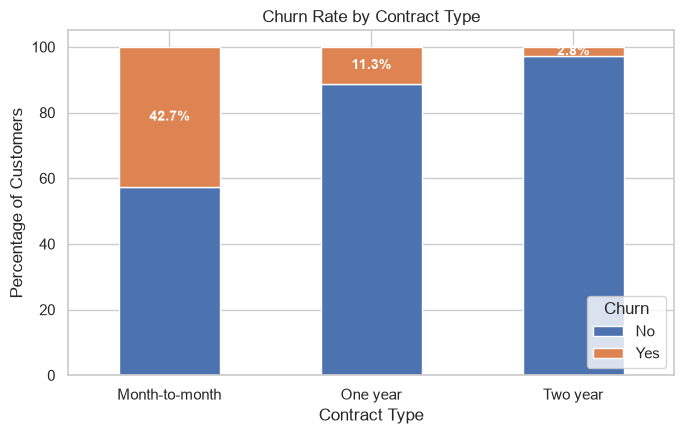

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [25]:
# --- Churn rate (%) by Contract type ---
contract_pct = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_order = ["Month-to-month", "One year", "Two year"]
contract_pct = contract_pct.loc[contract_order]

fig, ax = plt.subplots(figsize=(7, 4.5))
contract_pct.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"], ax=ax)

for i, contract in enumerate(contract_order):
    yes_pct = contract_pct.loc[contract, "Yes"]
    ax.text(i, 100 - yes_pct / 2, f"{yes_pct:.1f}%", ha="center", va="center", fontsize=10, color="white", fontweight="bold")

ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Percentage of Customers")
ax.set_xticklabels(contract_order, rotation=0)
ax.legend(title="Churn", loc="lower right")
plt.tight_layout()
plt.show()

print(contract_pct.round(2))

**Interpretation:** contract type is one of the strongest churn signals in the dataset. Churn rate drops sharply as commitment length increases: **42.7%** for month-to-month customers vs **11.3%** for one-year and just **2.8%** for two-year contracts — a ~15x difference between the extremes.

**Business insight:** month-to-month customers are the primary churn risk pool. Campaigns to migrate them onto one- or two-year contracts (e.g. discounts for longer commitments) are likely to be one of the most effective retention levers available.

### 6.3 Churn vs Internet Service type

**Business question:** Does the type of internet service (DSL, Fiber optic, or none) correlate with churn? This matters because it may point to service quality, pricing, or competitive issues specific to one type of internet offering.

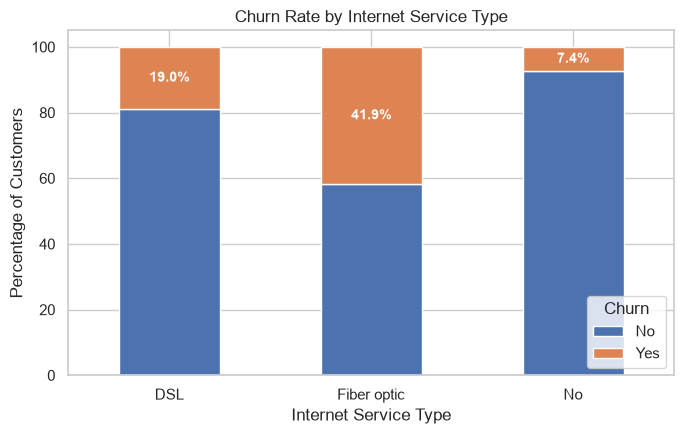

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


In [26]:
# --- Churn rate (%) by Internet Service type ---
internet_pct = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_order = ["DSL", "Fiber optic", "No"]
internet_pct = internet_pct.loc[internet_order]

fig, ax = plt.subplots(figsize=(7, 4.5))
internet_pct.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"], ax=ax)

for i, service in enumerate(internet_order):
    yes_pct = internet_pct.loc[service, "Yes"]
    ax.text(i, 100 - yes_pct / 2, f"{yes_pct:.1f}%", ha="center", va="center", fontsize=10, color="white", fontweight="bold")

ax.set_title("Churn Rate by Internet Service Type")
ax.set_xlabel("Internet Service Type")
ax.set_ylabel("Percentage of Customers")
ax.set_xticklabels(internet_order, rotation=0)
ax.legend(title="Churn", loc="lower right")
plt.tight_layout()
plt.show()

print(internet_pct.round(2))

**Interpretation:** customers with **Fiber optic** internet churn at **41.9%** — more than double the DSL rate (**19.0%**) and nearly 6x the rate of customers with no internet service (**7.4%**).

**Business insight:** Fiber optic is a premium, typically higher-priced product, yet it has the highest churn of any segment. This suggests the issue is unlikely to be the technology itself, but rather **price sensitivity, unmet service-quality expectations, or stronger competitive alternatives** for fiber customers. This is a strong candidate for deeper root-cause investigation (e.g. pricing tiers, support ticket volume) and combines with `MonthlyCharges` (Section 6.5) to point toward cost as a likely churn driver.

### 6.4 Churn vs Tenure

**Business question:** Are newer customers more likely to churn than long-tenured ones? If churn is concentrated in the early relationship, the business should focus retention effort on onboarding and the first few months, rather than spreading it evenly across the whole customer base.

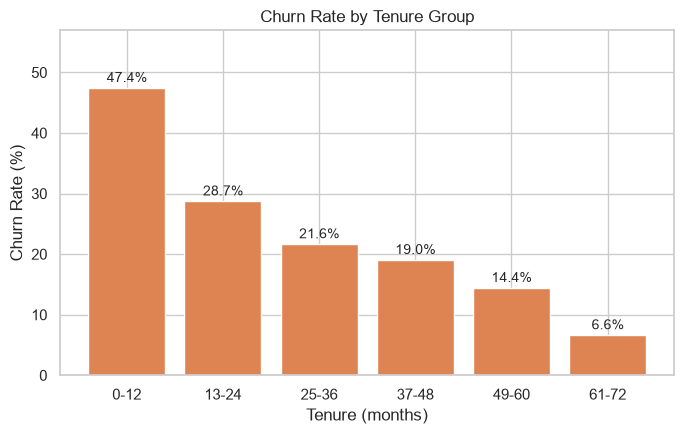

Churn            No    Yes
tenure_group              
0-12          52.56  47.44
13-24         71.29  28.71
25-36         78.37  21.63
37-48         80.97  19.03
49-60         85.58  14.42
61-72         93.39   6.61


In [27]:
# --- Churn rate (%) by tenure group ---
tenure_bins = [-1, 12, 24, 36, 48, 60, 72]
tenure_labels = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
df["tenure_group"] = pd.cut(df["tenure"], bins=tenure_bins, labels=tenure_labels)

tenure_pct = pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(tenure_labels, tenure_pct["Yes"], color="#DD8452")

for bar, pct in zip(bars, tenure_pct["Yes"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("Churn Rate by Tenure Group")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, tenure_pct["Yes"].max() * 1.2)
plt.tight_layout()
plt.show()

print(tenure_pct.round(2))

**Interpretation:** churn rate declines steadily and almost monotonically with tenure — from **47.4%** in the first year down to **6.6%** for customers with 61-72 months of tenure. Roughly half of brand-new customers churn within their first year.

**Business insight:** churn risk is heavily front-loaded. The first 12 months are the highest-risk, highest-impact window for retention efforts — improving onboarding, early engagement, and first-year offers is likely to yield a much larger reduction in churn than broad, tenure-agnostic retention campaigns. (Note: `tenure_group` is added to `df` here for this analysis and may be reused/refined as an engineered feature in Section 7.)

### 6.5 Churn vs Monthly Charges

**Business question:** Do customers who pay more per month churn at a higher rate? This tests whether price is a meaningful driver of churn, which would support pricing/discounting strategies as a retention tool.

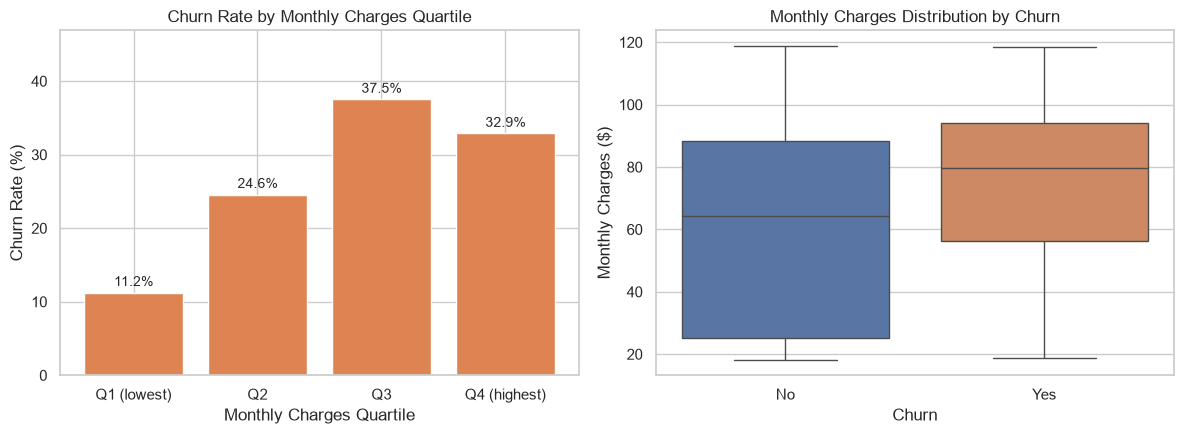

Churn                       No    Yes
MonthlyCharges_quartile              
Q1 (lowest)              88.76  11.24
Q2                       75.42  24.58
Q3                       62.49  37.51
Q4 (highest)             67.12  32.88

Median MonthlyCharges — No: 64.42500000000001 | Yes: 79.65


In [28]:
# --- Churn rate (%) by Monthly Charges quartile, plus distribution comparison ---
df["MonthlyCharges_quartile"] = pd.qcut(df["MonthlyCharges"], q=4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
charges_pct = pd.crosstab(df["MonthlyCharges_quartile"], df["Churn"], normalize="index") * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(charges_pct.index.astype(str), charges_pct["Yes"], color="#DD8452")
for bar, pct in zip(bars, charges_pct["Yes"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Churn Rate by Monthly Charges Quartile")
axes[0].set_xlabel("Monthly Charges Quartile")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, charges_pct["Yes"].max() * 1.25)

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=["No", "Yes"], hue="Churn", palette=["#4C72B0", "#DD8452"], legend=False, ax=axes[1])
axes[1].set_title("Monthly Charges Distribution by Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

print(charges_pct.round(2))
print("\nMedian MonthlyCharges — No:", df.loc[df["Churn"] == "No", "MonthlyCharges"].median(),
      "| Yes:", df.loc[df["Churn"] == "Yes", "MonthlyCharges"].median())

**Interpretation:** churn rate rises sharply from the lowest charges quartile (**11.2%**) to the third quartile (**37.5%**), then eases slightly for the highest-paying quartile (**32.9%**) — so the relationship is strong but not perfectly linear. The boxplot confirms this: churners have a noticeably higher median monthly bill (**$79.65**) than non-churners (**$64.43**).

**Business insight:** higher monthly charges are associated with meaningfully higher churn, reinforcing the pricing-sensitivity signal already seen with Fiber optic customers (Section 6.3) — the highest-paying segment is not the highest-risk one, which suggests price alone isn't the whole story (bundled value/perceived worth for the top payers may offset cost). This is a useful hypothesis to test further with a Decision Tree, since it can capture this kind of non-linear relationship better than a simple linear correlation would.

### 6.6 Churn vs Payment Method (additional analysis)

**Why this visualization:** the four checks above cover contract, service type, tenure, and price. Payment method is a distinct, actionable dimension — it reflects billing friction/convenience rather than product or pricing, and is worth checking before concluding the EDA.

**Business question:** does *how* a customer pays (automatic bank/credit card vs. manual electronic/mailed check) relate to churn? If manual payment methods are linked to higher churn, that may reflect a more disengaged or price-sensitive customer segment, or simply the friction of manual billing — both are addressable (e.g. promoting autopay enrollment).

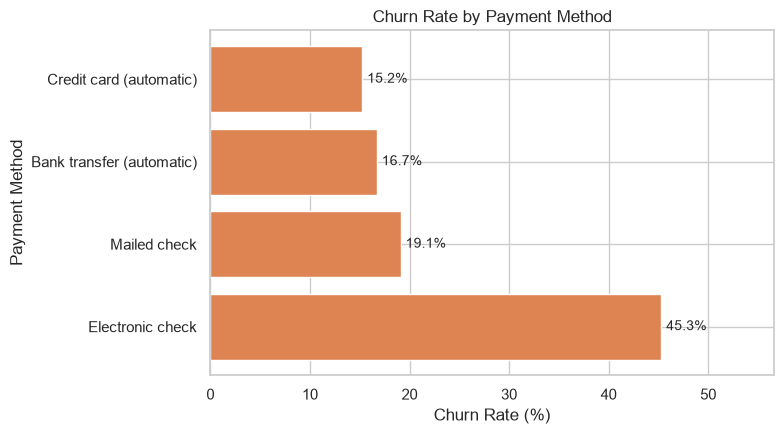

Churn                         No    Yes
PaymentMethod                          
Electronic check           54.71  45.29
Mailed check               80.89  19.11
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24


In [29]:
# --- Churn rate (%) by Payment Method ---
payment_pct = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment_pct = payment_pct.sort_values("Yes", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(payment_pct.index, payment_pct["Yes"], color="#DD8452")

for bar, pct in zip(bars, payment_pct["Yes"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}%", va="center", fontsize=10)

ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Churn Rate (%)")
ax.set_ylabel("Payment Method")
ax.set_xlim(0, payment_pct["Yes"].max() * 1.25)
plt.tight_layout()
plt.show()

print(payment_pct.round(2))

**Interpretation:** customers paying by **electronic check** churn at **45.3%** — roughly 2.4-4x the rate of any other payment method (credit card 15.2%, bank transfer 16.7%, mailed check 19.1%). Notably, the two *automatic* methods (bank transfer, credit card) have the lowest churn of all.

**Business insight:** electronic check is the single most concerning payment segment and, combined with month-to-month contracts and fiber internet, likely marks a cluster of disengaged, high-risk customers. Since automatic payment methods correlate with much lower churn, **encouraging enrollment in autopay** (bank transfer/credit card) is a concrete, low-cost retention action worth testing.

### 6.7 Churn vs number of add-on services subscribed

**Business question:** do customers without protective/support add-ons (online security, online backup, device protection, tech support) churn at a much higher rate than those with more of these services — and is there an upsell/bundling opportunity to reduce churn?

**Why this variable is relevant:** these four services showed the strongest untouched effect in the dataset during the EDA review (e.g. churn drops from ~42% to ~15% between customers without vs. with `OnlineSecurity`/`TechSupport`). Looking at them individually risks four near-duplicate charts, so instead we combine them into a single "number of add-on services subscribed" count (0-4) — a cleaner signal that also foreshadows the "total services subscribed" feature suggested for Section 7 (Feature Engineering).

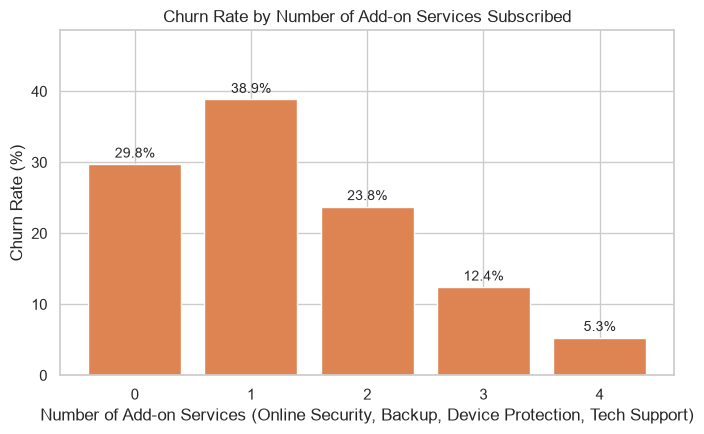

Churn           No    Yes
addon_count              
0            70.25  29.75
1            61.15  38.85
2            76.24  23.76
3            87.57  12.43
4            94.68   5.32

Customers per add-on count:
addon_count
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64


In [30]:
# --- Churn rate (%) by number of add-on services subscribed ---
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
df["addon_count"] = (df[addon_cols] == "Yes").sum(axis=1)

addon_pct = pd.crosstab(df["addon_count"], df["Churn"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(addon_pct.index.astype(str), addon_pct["Yes"], color="#DD8452")

for bar, pct in zip(bars, addon_pct["Yes"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("Churn Rate by Number of Add-on Services Subscribed")
ax.set_xlabel("Number of Add-on Services (Online Security, Backup, Device Protection, Tech Support)")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, addon_pct["Yes"].max() * 1.25)
plt.tight_layout()
plt.show()

print(addon_pct.round(2))
print("\nCustomers per add-on count:")
print(df["addon_count"].value_counts().sort_index())

**Interpretation:** from 1 add-on service onward, churn drops sharply and consistently — **38.9%** (1 service) → **23.8%** (2) → **12.4%** (3) → **5.3%** (4) — a clear, strong relationship. The one exception is the "0 add-ons" group, which is *lower* (29.8%) than the "1 add-on" group. This is because the "0" bucket mixes two different populations: customers who **have internet but chose no add-ons** (which is where the real risk is likely concentrated), and customers who **have no internet service at all** (whose baseline churn is already low, ~7.4%, as seen in Section 6.3) and are automatically counted as "0 add-ons" since the service doesn't apply to them. This blending flattens the 0-count bar and should be kept in mind if this feature is reused later (e.g. computing add-on count only among internet subscribers would give a cleaner picture).

**Business insight:** among customers who do have internet service, subscribing to more protective/support add-ons is strongly associated with staying — each additional service roughly halves the churn rate. This supports **actively promoting security/backup/support bundles** to internet customers with few or no add-ons, particularly combined with the fiber optic and month-to-month segments already flagged as high-risk.

### 6.8 Churn vs Senior Citizen status and Paperless Billing

**Business question:** are senior citizens, and/or customers on paperless billing, disproportionately likely to churn — pointing to a demographic segment or a billing-channel/communication-preference issue that needs a different retention approach?

**Why these variables are relevant:** both showed a strong, previously unexplored split in the EDA review — `SeniorCitizen` (~24% vs ~42%) and `PaperlessBilling` (~16% vs ~34%) — but tell two distinct stories (age-related vs. billing-channel), so they're paired here as a compact side-by-side comparison rather than two separate full analyses.

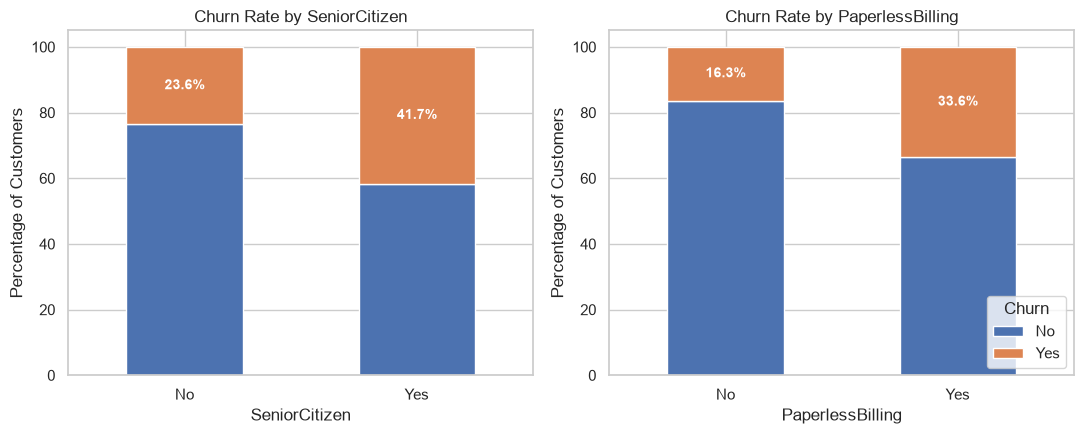

SeniorCitizen:
Churn             No    Yes
SeniorCitizen              
No             76.39  23.61
Yes            58.32  41.68

PaperlessBilling:
Churn                No    Yes
PaperlessBilling              
No                83.67  16.33
Yes               66.43  33.57


In [31]:
# --- Churn rate (%) by SeniorCitizen and PaperlessBilling ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, col, order_ in zip(axes, ["SeniorCitizen", "PaperlessBilling"], [["No", "Yes"], ["No", "Yes"]]):
    pct = pd.crosstab(df[col], df["Churn"], normalize="index").loc[order_] * 100
    pct.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"], ax=ax, legend=False)
    for i, cat in enumerate(order_):
        yes_pct = pct.loc[cat, "Yes"]
        ax.text(i, 100 - yes_pct / 2, f"{yes_pct:.1f}%", ha="center", va="center", fontsize=10, color="white", fontweight="bold")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Percentage of Customers")
    ax.set_xticklabels(order_, rotation=0)

axes[1].legend(title="Churn", loc="lower right")
plt.tight_layout()
plt.show()

print("SeniorCitizen:")
print((pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100).round(2))
print("\nPaperlessBilling:")
print((pd.crosstab(df["PaperlessBilling"], df["Churn"], normalize="index") * 100).round(2))

**Interpretation:** senior citizens churn at **41.7%** vs **23.6%** for non-seniors — nearly double. Customers on paperless billing churn at **33.6%** vs **16.3%** for paper billing — almost exactly double as well. Both are large, standalone effects.

**Business insight:** these two segments likely need different retention approaches. Senior citizens may benefit from simplified plans, more accessible customer support, or proactive check-ins, since age-related friction (not price or contract terms) appears to be the driver. Paperless billing's higher churn is counterintuitive at first (digital billing is usually linked to more engaged, tech-savvy customers), so it's more likely acting as a **proxy for the same customer profile already identified** — younger, more price-sensitive, month-to-month customers who are also comfortable switching providers — rather than a cause of churn on its own. It should be interpreted as a correlated signal, not a lever to pull directly (e.g. switching someone to paper billing is very unlikely to reduce their churn risk).

### Updated Section 6 summary
Across all eight analyses, the clearest churn drivers are: **short-term contracts, fiber optic internet with higher monthly charges, manual/electronic-check payment, few or no add-on services, and senior citizen status** — with paperless billing acting as a correlated (not causal) marker of the same at-risk profile. Churn risk is also heavily concentrated in the **first 12 months of tenure**. These patterns motivate the engineered features and modeling choices in the following sections.

## 7. Feature Engineering

Create at least 2 new features derived from existing columns (e.g. tenure grouping, total services subscribed), with an explanation of how each was built and why it may help predict churn.

**Why this section is required:** the assignment explicitly requires at least 2 engineered features, each justified in terms of construction and business/predictive rationale.

**Decision:** of the 5 candidate features discussed, we implement the **2 strongest and least caveated**:
1. **Total number of services subscribed** — broad, strong EDA signal, no leakage, fully computable for a new customer at signup.
2. **Tenure group ("new customer" bucket)** — the single strongest relationship found in the EDA, no leakage, computable for any customer (a brand-new signup simply falls in the highest-risk bucket).

The other 3 candidates (average monthly spend, autopay flag, composite high-risk flag) are **not implemented**: the first degrades for brand-new customers (no `TotalCharges` history yet), the second is largely redundant with `PaymentMethod` once encoded, and the third is an interaction a Decision Tree can already reconstruct on its own via successive splits — none added enough incremental value to justify the extra complexity right now.

### 7.1 Feature: `TotalServices` — total number of services subscribed

**How it's calculated:** count of `"Yes"` across the 8 add-on/phone service columns (`PhoneService`, `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`), plus 1 if the customer has any internet service at all (`InternetService != "No"`). Range: 0-9.

**Why it may help predict churn:** extends the pattern already seen in Section 6.7 (add-on count alone) to the full service footprint — customers with more services subscribed are more embedded in the ecosystem and, per the EDA, churn markedly less.

**Business meaning:** a simple proxy for customer engagement/switching cost — useful for prioritizing upsell and bundling offers.

**Data leakage:** none — built only from subscription flags, independent of `Churn`.

**New customer via API:** fully computable at signup, since service selections are known immediately.

In [32]:
# --- Engineer TotalServices (and tenure_group) using the shared feature-engineering module ---
# This is the same module the future Day 2 FastAPI app will import, so training and serving
# always compute these features identically (see src/feature_engineering.py).
import sys

# Reuse PROJECT_ROOT resolved in Section 2 - no need to re-derive the path here.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_engineering import engineer_features, service_cols

df = engineer_features(df)

print(df["TotalServices"].describe())
print("\nCustomers per TotalServices value:")
print(df["TotalServices"].value_counts().sort_index())

print("\nChurn rate (%) by TotalServices:")
print((pd.crosstab(df["TotalServices"], df["Churn"], normalize="index") * 100).round(2))

count    7043.000000
mean        4.146244
std         2.312720
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: TotalServices, dtype: float64

Customers per TotalServices value:
TotalServices
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64

Churn rate (%) by TotalServices:
Churn             No    Yes
TotalServices              
1              89.08  10.92
2              69.03  30.97
3              55.08  44.92
4              63.52  36.48
5              68.66  31.34
6              74.45  25.55
7              77.51  22.49
8              87.59  12.41
9              94.71   5.29


**Observed pattern:** churn is **not** simply monotonic in `TotalServices`. It starts low (10.9% at 1 service — mostly phone-only customers with no internet, consistent with the low baseline churn seen for `InternetService == "No"` in Section 6.3), **rises to a peak of 44.9% at 3 services** (likely internet + a couple of add-ons, matching the earlier finding that fiber-optic customers with few protective add-ons are especially high-risk), then **declines steadily from 4 services onward down to 5.3% at 9 services**.

This is a good example of why a Decision Tree (which can split on non-linear/non-monotonic thresholds) is a better fit for this relationship than a simple linear model would be — the raw feature still carries strong information, even though it isn't a straight-line trend.

### 7.2 Feature: `tenure_group` — tenure bucketed into ranges

**How it's calculated:** `tenure` (months) binned into 6 ranges: `0-12`, `13-24`, `25-36`, `37-48`, `49-60`, `61-72`. (This was first introduced in Section 6.4 for EDA purposes; here we formally adopt it as a modeling feature.)

**Why it may help predict churn:** Section 6.4 showed churn falling almost monotonically from 47.4% (0-12 months) to 6.6% (61-72 months) — one of the strongest single relationships found in the whole EDA. Bucketing makes this "high-risk first year" threshold explicit for the model, on top of the raw `tenure` value.

**Business meaning:** directly identifies the retention team's highest-priority window (new customers, first 12 months) versus long-tenured, low-risk customers.

**Data leakage:** none — derived only from `tenure`, independent of `Churn`.

**New customer via API:** yes, trivially — a brand-new signup has `tenure = 0` and always falls into the `0-12` (highest-risk) bucket. This makes the feature most informative for existing customers with some history; for a customer at the exact moment of signup it's a constant, so it adds no discriminative power until they've been active a while — still valid to compute and use.

In [33]:
# --- Confirm tenure_group (already built in Section 6.4) is present and adopted as a feature ---
print("dtype:", df["tenure_group"].dtype)
print("\nCustomers per tenure_group:")
print(df["tenure_group"].value_counts().sort_index())
print("\nChurn rate (%) by tenure_group:")
print((pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100).round(2))

dtype: category

Customers per tenure_group:
tenure_group
0-12     2186
13-24    1024
25-36     832
37-48     762
49-60     832
61-72    1407
Name: count, dtype: int64

Churn rate (%) by tenure_group:
Churn            No    Yes
tenure_group              
0-12          52.56  47.44
13-24         71.29  28.71
25-36         78.37  21.63
37-48         80.97  19.03
49-60         85.58  14.42
61-72         93.39   6.61


### 7.3 Example values and verification for unseen/new customer data

Below: (a) example rows from the training data showing both engineered features alongside their source columns, and (b) a standalone function that computes both features from a raw customer record — the same shape of input the future API would receive — to confirm they can be calculated for a brand-new, unseen customer with no churn history.

In [34]:
# --- Example values: engineered features alongside their source columns ---
example_cols = ["customerID", "tenure", "tenure_group", "InternetService"] + service_cols + ["TotalServices", "Churn"]
df[example_cols].sample(5, random_state=42)

,customerID,tenure,tenure_group,InternetService,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,TotalServices,Churn
185,1024-GUALD,1,0-12,DSL,No,No phone service,No,No,No,No,No,No,1,Yes
2715,0484-JPBRU,41,37-48,No,Yes,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,2,No
3825,3620-EHIMZ,52,49-60,No,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,1,No
1807,6910-HADCM,1,0-12,Fiber optic,Yes,No,No,No,Yes,No,No,No,3,Yes
132,8587-XYZSF,67,61-72,DSL,Yes,No,No,No,No,Yes,No,No,3,No


In [35]:
# --- Verify both features can be computed for a brand-new, unseen customer (simulating the future API input) ---
# engineer_features() (imported from src/feature_engineering.py in Section 7.1) is the SAME
# function that will be used by the Day 2 FastAPI app - no separate/duplicate implementation here.

# A brand-new signup: just joined (tenure=0), phone only, no internet yet
new_customer_a = {
    "tenure": 0, "InternetService": "No", "PhoneService": "Yes", "MultipleLines": "No",
    "OnlineSecurity": "No internet service", "OnlineBackup": "No internet service",
    "DeviceProtection": "No internet service", "TechSupport": "No internet service",
    "StreamingTV": "No internet service", "StreamingMovies": "No internet service",
}

# A brand-new signup: just joined (tenure=0), fiber + several add-ons
new_customer_b = {
    "tenure": 0, "InternetService": "Fiber optic", "PhoneService": "Yes", "MultipleLines": "Yes",
    "OnlineSecurity": "Yes", "OnlineBackup": "Yes", "DeviceProtection": "No",
    "TechSupport": "Yes", "StreamingTV": "No", "StreamingMovies": "No",
}

# A single customer record is just a 1-row DataFrame - the same function used on the
# full training/test dataset in Section 7.1 works here unchanged.
result_a = engineer_features(pd.DataFrame([new_customer_a])).iloc[0]
result_b = engineer_features(pd.DataFrame([new_customer_b])).iloc[0]

print("New customer A ->", {"TotalServices": result_a["TotalServices"], "tenure_group": result_a["tenure_group"]})
print("New customer B ->", {"TotalServices": result_b["TotalServices"], "tenure_group": result_b["tenure_group"]})

# --- Small verification: the shared function produces the expected values ---
assert result_a["TotalServices"] == 1 and result_a["tenure_group"] == "0-12"
assert result_b["TotalServices"] == 6 and result_b["tenure_group"] == "0-12"
print("\nVerified: the shared engineer_features() function produces the correct TotalServices and tenure_group values.")

New customer A -> {'TotalServices': np.int64(1), 'tenure_group': '0-12'}
New customer B -> {'TotalServices': np.int64(6), 'tenure_group': '0-12'}

Verified: the shared engineer_features() function produces the correct TotalServices and tenure_group values.


**Verification result:** both features compute successfully for brand-new customers with `tenure = 0` and no churn/billing history — customer A (phone only, no internet) gets `TotalServices=1, tenure_group="0-12"`, and customer B (fiber + several add-ons) gets `TotalServices=6, tenure_group="0-12"`. This confirms neither feature depends on `TotalCharges`, `Churn`, or any information that only exists after a customer relationship has developed, so both are safe and ready to use in the Day 2 prediction API, exactly as promised in Section 7. Because this is the exact same `engineer_features()` function imported from `src/feature_engineering.py` (not a separate copy), this is also a direct verification that training-time and future serving-time feature engineering will always match.

### Section 7 summary
Two features were engineered and added to `df`: **`TotalServices`** (0-9, total services subscribed) and **`tenure_group`** (6-bucket tenure range, reused from Section 6.4). Both are leakage-free (derived only from pre-existing predictor columns, never from `Churn`) and both are computable for a brand-new customer submitted to the future API — `tenure_group` simply defaults to the `0-12` (highest-risk) bucket at signup. The 3 remaining candidates (average monthly spend, autopay flag, composite high-risk flag) were documented but intentionally not implemented, for the reasons given above.

## 8. Train/Test Split

Split the cleaned, feature-engineered dataset into training and test sets using a 70:30 ratio with `random_state=42`, stratified on `Churn`.

**Why this section is required:** the assignment mandates a 70:30 split with a fixed seed for reproducibility, and the split must happen before fitting any preprocessing step to avoid data leakage from the test set.

In [36]:
from sklearn.model_selection import train_test_split

# Separate predictors (X) from the target (y). customerID is an identifier, not a predictor,
# so it is dropped here (it carries no generalizable signal and would only add noise/leakage risk).
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (4930, 23)
X_test shape:  (2113, 23)
y_train shape: (4930,)
y_test shape:  (2113,)


In [37]:
# Target distribution in each split, to confirm stratification preserved the ~73.5% / 26.5% Churn ratio
train_dist = y_train.value_counts(normalize=True).mul(100).round(2)
test_dist = y_test.value_counts(normalize=True).mul(100).round(2)

dist_compare = pd.DataFrame({
    "Full dataset (%)": y.value_counts(normalize=True).mul(100).round(2),
    "Train (%)": train_dist,
    "Test (%)": test_dist,
})
dist_compare

,Full dataset (%),Train (%),Test (%)
Churn,,,
No,73.46,73.47,73.45
Yes,26.54,26.53,26.55


**Result:** `X_train` has 4,930 rows and `X_test` has 2,113 rows — a 70:30 split of the 7,043 total. The Churn ratio is preserved almost exactly: 73.47%/26.53% in train vs. 73.45%/26.55% in test, both matching the full dataset's 73.46%/26.54%.

**Why we split before fitting any preprocessing:** as discussed above, any statistic learned from the data (an imputed mean, an encoder's category list, a scaler's min/max) must come only from data the model is "allowed" to have seen. Splitting first and fitting preprocessing only on `X_train` in Section 9 guarantees the test set stays a clean, untouched stand-in for genuinely new customers — so the evaluation metrics we report will be a realistic estimate of production performance, not an inflated one caused by the model (or its preprocessing) indirectly learning from test rows.

**What stratification does and why it matters here:** `stratify=y` forces `train_test_split` to preserve the original 73.46%/26.54% Churn ratio in both the training and test partitions, instead of leaving it to chance. This matters for churn prediction because the target is **imbalanced** (churners are the minority class, ~1 in 4 customers). Without stratification, a random split could easily under- or over-represent churners in the test set purely by luck, which would make evaluation metrics (recall/precision for the churn class especially) noisy and unreliable run-to-run. Stratifying removes that variance so any differences we see later are due to the model, not an accidental imbalance introduced by the split itself.

Model training has not been started — this section only performs the split.

## 9. Data Preprocessing

Build a preprocessing pipeline (e.g. `ColumnTransformer` with encoding for categorical variables) fit only on the training set, then applied to transform both training and test sets identically.

**Why this section is required:** the assignment requires "encoding of categorical variables" and stresses that preprocessing must "avoid data leakage" and be "applied consistently to new/unseen data" — bundling it as a fitted, reusable pipeline is what makes that possible.

### 9.1 Curate the modeling feature set

Before splitting columns into numerical/categorical groups, we drop two EDA-only helper columns that are still sitting in `X_train`/`X_test`:

- **`MonthlyCharges_quartile`** — built in Section 6.5 using `pd.qcut(df["MonthlyCharges"], q=4, ...)`. `qcut` computes its bin *edges* from the data itself (equal-frequency quantiles), and those edges were computed on the **full 7,043-row dataset before the train/test split**. That means the exact cutoffs were influenced by MonthlyCharges values that ended up in the test set — precisely the "statistic computed on data the model shouldn't have seen yet" leakage pattern we just discussed. It was only ever intended as an EDA visualization aid, not a modeling feature, so we exclude it here rather than try to recompute it safely.
- **`addon_count`** — built in Section 6.7 as an EDA aid; it's redundant with `TotalServices` (which already counts add-on services plus phone/internet) and was never formally adopted as an engineered feature in Section 7.

The raw `MonthlyCharges` column (unbinned) is kept, so no information is lost — the model can learn its own splits on the continuous value without inheriting a leakage-tainted binning.

In [38]:
eda_only_cols = ["MonthlyCharges_quartile", "addon_count"]
X_train = X_train.drop(columns=eda_only_cols)
X_test = X_test.drop(columns=eda_only_cols)

print("Dropped EDA-only columns:", eda_only_cols)
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\nRemaining columns:\n", list(X_train.columns))

Dropped EDA-only columns: ['MonthlyCharges_quartile', 'addon_count']
X_train shape: (4930, 21)
X_test shape:  (2113, 21)

Remaining columns:
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group', 'TotalServices']


In [39]:
# Identify numerical vs. categorical features from the actual dtypes (not hard-coded), so this
# stays correct if the feature set changes later.
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["str", "category"]).columns.tolist()

# tenure_group has a natural order (0-12 < 13-24 < ... < 61-72), so it gets an OrdinalEncoder
# to preserve that order instead of exploding it into unordered one-hot columns.
ordinal_features = ["tenure_group"]
nominal_features = [c for c in categorical_features if c not in ordinal_features]

print("Numeric features (%d):" % len(numeric_features), numeric_features)
print("\nOrdinal categorical features (%d):" % len(ordinal_features), ordinal_features)
print("\nNominal categorical features (%d):" % len(nominal_features), nominal_features)

Numeric features (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']

Ordinal categorical features (1): ['tenure_group']

Nominal categorical features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 9.2 Build the preprocessing pipeline

Three parallel branches, one per feature group, combined by a `ColumnTransformer`:

- **Numeric** (`tenure`, `MonthlyCharges`, `TotalCharges`, `TotalServices`): median imputation only. No scaling — the planned model (Decision Tree) splits on raw thresholds and is invariant to monotonic transformations like standardization, so scaling would add complexity with no benefit. Median (not mean) is used for robustness in case a skewed numeric column ever has missing values.
- **Nominal categorical** (gender, Contract, PaymentMethod, etc.): most-frequent imputation + `OneHotEncoder(handle_unknown="ignore")`. `handle_unknown="ignore"` matters for the unseen-data requirement — if a brand-new customer ever arrives with a category the encoder never saw during training, it's encoded as all-zeros instead of crashing.
- **Ordinal categorical** (`tenure_group` only): most-frequent imputation + `OrdinalEncoder`, with the category order fixed explicitly to `tenure_labels` so "0-12" < "13-24" < ... is preserved as a single meaningful number rather than 6 unordered one-hot columns.

Imputers are included even though the training data currently has zero missing values (Section 5 already handled that) — they're there so the *same* pipeline doesn't break if an unseen customer record has a blank field at prediction time.

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Numeric branch: impute only (Decision Trees don't need scaling)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

# Nominal categorical branch: impute + one-hot encode, ignoring categories never seen in training
nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Ordinal categorical branch: impute + encode preserving the natural tenure order
ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[tenure_labels], handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat_nominal", nominal_transformer, nominal_features),
    ("cat_ordinal", ordinal_transformer, ordinal_features),
])

# Wrapping in a Pipeline (even with just one step for now) means Section 10 can later
# append a ("classifier", DecisionTreeClassifier(...)) step to this exact same object.
preprocessing_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
])

preprocessing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

### 9.3 Fit on training data only, then transform both sets

`fit_transform` is called only on `X_train` — this is the step that "learns" the median values, the one-hot category vocabulary, and the ordinal mapping, using training rows exclusively. `X_test` then only ever goes through `transform`, reusing those already-learned parameters. This is the practical implementation of the leakage-prevention rule from earlier: nothing about the test set influenced how any value gets imputed or encoded.

In [41]:
# Fit only on X_train (learns medians, one-hot categories, ordinal mapping from training rows only)
X_train_transformed = preprocessing_pipeline.fit_transform(X_train)

# Test data only ever goes through transform() — reusing what was already learned from training
X_test_transformed = preprocessing_pipeline.transform(X_test)

feature_names = preprocessing_pipeline.named_steps["preprocessor"].get_feature_names_out()

print("X_train_transformed shape:", X_train_transformed.shape)
print("X_test_transformed shape: ", X_test_transformed.shape)
print("Number of output features after encoding:", len(feature_names))
print("\nFirst 10 output feature names:", list(feature_names[:10]))

X_train_transformed shape: (4930, 48)
X_test_transformed shape:  (2113, 48)
Number of output features after encoding: 48

First 10 output feature names: ['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'num__TotalServices', 'cat_nominal__gender_Female', 'cat_nominal__gender_Male', 'cat_nominal__SeniorCitizen_No', 'cat_nominal__SeniorCitizen_Yes', 'cat_nominal__Partner_No', 'cat_nominal__Partner_Yes']


### 9.4 Verify the same pipeline works on unseen/new customer data

The whole point of fitting the pipeline once is that it becomes a reusable object: any future customer record — with the same raw columns, before any manual preprocessing — can be passed straight through `.transform()` and come out ready for the model. Below, a brand-new, never-before-seen customer record (built the same way the future API would receive it) is run through the already-fitted pipeline to confirm this works, including its engineered `TotalServices`/`tenure_group` fields from Section 7.

In [42]:
# A brand-new customer signing up today: never appeared in training or test data.
# TotalCharges is 0 at signup (no billing history yet), matching the Section 5 imputation rule.
new_customer_raw = {
    "gender": "Female", "SeniorCitizen": "No", "Partner": "Yes", "Dependents": "No",
    "tenure": 0, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "Yes",
    "DeviceProtection": "No", "TechSupport": "Yes", "StreamingTV": "No", "StreamingMovies": "No",
    "Contract": "Month-to-month", "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.50, "TotalCharges": 0.0,
}

# Reuse the shared engineer_features() function (src/feature_engineering.py) so the engineered
# columns are produced with the exact same logic used on the training data.
new_customer_df = engineer_features(pd.DataFrame([new_customer_raw]))[X_train.columns]  # match training column order
new_customer_transformed = preprocessing_pipeline.transform(new_customer_df)

print("New customer raw record produced engineered features:",
      new_customer_df[["TotalServices", "tenure_group"]].iloc[0].to_dict())
print("Transformed shape:", new_customer_transformed.shape, "(matches the 48 training features)")

New customer raw record produced engineered features: {'TotalServices': 4, 'tenure_group': '0-12'}
Transformed shape: (1, 48) (matches the 48 training features)


### 9.5 Pipeline walkthrough and why this beats manual preprocessing

```mermaid
flowchart LR
    A["Raw customer data\n21 columns: numeric + categorical\n(train, test, or a brand-new record)"] --> B["Numerical/categorical separation\nnumeric_features (4)\nnominal_features (16)\nordinal_features (1)"]
    B --> C["Transformations\nnum: median impute\ncat_nominal: impute + OneHotEncoder\ncat_ordinal: impute + OrdinalEncoder\n(fit ONLY on X_train)"]
    C --> D["Transformed features\n48 numeric columns\n(same shape for train, test, new data)"]
    D --> E["Model\n(Section 10 — Decision Tree,\nnot trained yet)"]
```

**Step by step:**
1. **Raw customer data** — whatever comes in (a training row, a test row, or a brand-new signup) starts in the same raw shape: 21 columns, mixed types, human-readable categories like `"Fiber optic"` or `"Month-to-month"`.
2. **Numerical/categorical separation** — `ColumnTransformer` routes each column to the branch that matches its type: 4 numeric columns, 16 nominal categorical columns, 1 ordinal categorical column (`tenure_group`).
3. **Transformations** — each branch applies its own small `Pipeline` (impute, then encode/scale as needed). Critically, `.fit_transform()` was called only on `X_train` in Section 9.3; test and new data only ever call `.transform()`, so no test-set or future-customer information ever leaks into how values get imputed or encoded.
4. **Transformed features** — everything comes out as one 48-column numeric matrix, in the exact same column order regardless of whether the input was `X_train`, `X_test`, or the simulated new customer above.
5. **Model** — Section 10 will append a `DecisionTreeClassifier` as one more step in this same `Pipeline`, so the whole thing (preprocessing + model) becomes a single fitted object.

**Why `ColumnTransformer` + `Pipeline` beat manually preprocessing the whole dataset before the split:**
- **Structural leakage prevention, not just discipline.** Manually preprocessing the full dataset (e.g., calling `OneHotEncoder().fit_transform(df)` before splitting) forces every statistic to be learned from all the data, including future test rows — exactly the mistake this file's earlier leakage discussion warned about. With `ColumnTransformer`/`Pipeline`, `fit()` and `transform()` are separate, deliberate calls, so it's structurally harder to accidentally fit on the wrong data.
- **One object instead of scattered logic.** All three branches (numeric, nominal, ordinal) are bundled into one estimator. There's no risk of forgetting to apply one column's transformation consistently, or applying it in a different order to train vs. test.
- **Directly reusable for new/unseen data.** As shown in Section 9.4, the identical fitted `preprocessing_pipeline` object handles a brand-new customer record with zero code changes — this is exactly what the future prediction API will call.
- **Safe for cross-validation.** If Section 10 uses `cross_val_score` or `GridSearchCV` on this `Pipeline`, sklearn automatically refits the preprocessing on each fold's training portion only — something manual pre-split preprocessing could never do correctly, since the split would already be "baked in" before cross-validation even starts.

Model training has not been started — this section only builds and verifies the preprocessing pipeline.

## 10. Decision Tree Model Development

Train a `DecisionTreeClassifier` on the training data, experimenting with at least two different configurations (e.g. varying `max_depth`, `min_samples_leaf`, or `criterion`), compare them, and select/justify a final model.

**Why this section is required:** the assignment explicitly requires building a Decision Tree, experimenting with at least two configurations, comparing them, and justifying the final choice.

### 10.1 Two Decision Tree configurations

Two deliberately different configurations, varying `max_depth`, `min_samples_split`, and `min_samples_leaf` together (a shallow/constrained tree vs. a deeper/flexible one), so the comparison reflects a real bias-variance trade-off rather than a single tweaked knob. `criterion` and `class_weight` are left at their defaults for both — isolating the depth/split/leaf effect — and extensive tuning (grid search, cross-validation) is intentionally deferred, as instructed.

- **Model A — shallow & regularized**: `max_depth=4`, `min_samples_split=50`, `min_samples_leaf=25`. Forces the tree to stop splitting early and requires large groups of customers before creating a rule — biased toward simple, broad, human-readable patterns (e.g. "month-to-month + fiber + low tenure").
- **Model B — deeper & flexible**: `max_depth=10`, `min_samples_split=10`, `min_samples_leaf=5`. Allows many more splits on smaller subgroups — can capture finer-grained interactions between features, at higher risk of fitting noise specific to the training set.

Both use `random_state=42` for reproducibility, and each is wrapped in its own `Pipeline` combining a **fresh copy of the Section 9 preprocessor** with the classifier, so preprocessing and model selection stay bundled per the leakage-safe design from Section 9.

In [43]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier

model_configs = {
    "Model A (shallow, regularized)": DecisionTreeClassifier(
        max_depth=4, min_samples_split=50, min_samples_leaf=25, random_state=42
    ),
    "Model B (deeper, flexible)": DecisionTreeClassifier(
        max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42
    ),
}

fitted_pipelines = {}
results = []

for name, clf in model_configs.items():
    # clone(preprocessor) gives each model its own independent, unfitted copy of the
    # Section 9 ColumnTransformer, so each Pipeline is fully self-contained.
    pipe = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", clf),
    ])
    pipe.fit(X_train, y_train)  # trains on training data only
    y_pred = pipe.predict(X_test)  # predictions on held-out test data

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Churn=Yes)": precision_score(y_test, y_pred, pos_label="Yes"),
        "Recall (Churn=Yes)": recall_score(y_test, y_pred, pos_label="Yes"),
        "F1 (Churn=Yes)": f1_score(y_test, y_pred, pos_label="Yes"),
    })
    fitted_pipelines[name] = pipe

comparison_df = pd.DataFrame(results).set_index("Model").round(4)
comparison_df

,Accuracy,Precision (Churn=Yes),Recall (Churn=Yes),F1 (Churn=Yes)
Model,,,,
"Model A (shallow, regularized)",0.7918,0.6580,0.4492,0.5339
"Model B (deeper, flexible)",0.7653,0.5619,0.5258,0.5433


In [44]:
# Quick check: training-set accuracy for each model, to see how much each overfits
# (train accuracy far above test accuracy = the model memorized training-specific patterns).
train_vs_test = pd.DataFrame({
    "Model": list(model_configs.keys()),
    "Train Accuracy": [accuracy_score(y_train, pipe.predict(X_train)) for pipe in fitted_pipelines.values()],
    "Test Accuracy": [accuracy_score(y_test, pipe.predict(X_test)) for pipe in fitted_pipelines.values()],
}).set_index("Model").round(4)
train_vs_test["Gap (Train - Test)"] = (train_vs_test["Train Accuracy"] - train_vs_test["Test Accuracy"]).round(4)
train_vs_test

,Train Accuracy,Test Accuracy,Gap (Train - Test)
Model,,,
"Model A (shallow, regularized)",0.7978,0.7918,0.0060
"Model B (deeper, flexible)",0.8598,0.7653,0.0945


### 10.2 Trade-offs and recommendation

**What the numbers show:**

| | Model A (shallow) | Model B (deeper) |
|---|---|---|
| Accuracy | 0.7918 | 0.7653 |
| Precision (Churn=Yes) | 0.6580 | 0.5619 |
| Recall (Churn=Yes) | 0.4492 | 0.5258 |
| F1 (Churn=Yes) | 0.5339 | 0.5433 |
| Train − Test accuracy gap | 0.0060 | 0.0945 |

Model A has the **higher accuracy and precision**; Model B has the **higher recall and (marginally) higher F1**. Neither model dominates on every metric, so picking "the winner" purely on accuracy — which is what the assignment explicitly warns against — would be the wrong move here, and would also hide an important problem: Model B's ~9.4-point train/test accuracy gap (vs. ~0.6 points for Model A) shows it is **overfitting** — it memorized training-specific patterns that don't generalize, which is exactly the risk of letting a tree grow deep (`max_depth=10`) with small leaves (`min_samples_leaf=5`) on a moderately-sized dataset.

**Why this trade-off matters for the churn business problem:** in a retention use case, missing an actual churner (a **false negative**, i.e. low recall) means a customer leaves with zero chance to intervene — pure lost revenue. Flagging a loyal customer as at-risk (a **false positive**, i.e. lower precision) is far cheaper: it just means an unnecessary retention offer (a discount or a phone call) sent to someone who wasn't going to leave anyway. This asymmetry generally favors **prioritizing recall over precision** for churn identification — a point we'll return to more formally with a confusion matrix in Section 11.

**Recommendation:** despite Model A's higher accuracy/precision, **Model B (deeper, flexible)** is the more business-appropriate choice going into Section 11, because its higher recall (0.5258 vs. 0.4492) means it catches meaningfully more of the customers who actually churn — directly serving the retention goal — and its F1 is also marginally better. The overfitting gap is a real concern, not a reason to discard the model outright: it's a signal that **hyperparameter tuning** (reducing `max_depth`, increasing `min_samples_leaf`, or cross-validating instead of a single split) could likely close much of that gap while keeping the recall advantage — exactly the kind of refinement earmarked as bonus tuning work for Day 3. Model A remains a solid, more conservative fallback if interpretability and stability are prioritized over catching every possible churner.

No further hyperparameter tuning has been performed at this stage, per the instructions.

## 11. Model Evaluation

Evaluate the final model on the test set using Accuracy, Precision, Recall, F1 Score, and a Confusion Matrix, then interpret the results from a business perspective — including whether Precision or Recall should be prioritized for churn identification.

**Why this section is required:** the assignment requires this specific set of metrics plus a business interpretation, and explicitly asks us to justify a Precision vs. Recall priority for a telecom retention use case.

### 11.1 Metrics for the selected final model

Section 10 recommended **Model B (deeper, flexible)** for its higher recall on the churn class, despite its slightly lower accuracy. This section evaluates that model on the test set in full: Accuracy, Precision, Recall, F1, and a confusion matrix.

In [45]:
final_model_name = "Model B (deeper, flexible)"
final_model = fitted_pipelines[final_model_name]
y_pred_final = final_model.predict(X_test)

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision (Churn=Yes)": precision_score(y_test, y_pred_final, pos_label="Yes"),
    "Recall (Churn=Yes)": recall_score(y_test, y_pred_final, pos_label="Yes"),
    "F1 (Churn=Yes)": f1_score(y_test, y_pred_final, pos_label="Yes"),
}

print(f"Final model: {final_model_name}\n")
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

Final model: Model B (deeper, flexible)

Accuracy: 0.7653
Precision (Churn=Yes): 0.5619
Recall (Churn=Yes): 0.5258
F1 (Churn=Yes): 0.5433


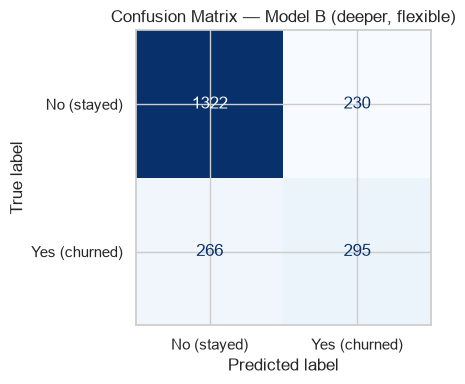

True Negatives (TN):  1322
False Positives (FP): 230
False Negatives (FN): 266
True Positives (TP):  295


In [46]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_final, labels=["No", "Yes"])

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No (stayed)", "Yes (churned)"])
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(f"Confusion Matrix — {final_model_name}")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

### 11.2 What TP, TN, FP, and FN mean here

Using the actual confusion matrix above (2,113 test customers total):

- **True Positive (TP = 295):** the model predicted **"will churn"** and the customer **actually churned**. Example: a month-to-month, fiber-optic customer with low tenure is flagged as at-risk, and they do in fact cancel — the retention team could have targeted them.
- **True Negative (TN = 1,322):** the model predicted **"will stay"** and the customer **actually stayed**. Example: a two-year-contract customer with several add-on services is correctly left alone — no wasted retention effort.
- **False Positive (FP = 230):** the model predicted **"will churn"** but the customer **actually stayed**. Example: a customer gets an unnecessary retention offer (a discount, a call from support) even though they were never going to leave — a "wasted alarm."
- **False Negative (FN = 266):** the model predicted **"will stay"** but the customer **actually churned**. Example: a customer who was quietly planning to switch providers is missed entirely, receives no outreach, and leaves — a **missed retention opportunity**.

### 11.3 Business interpretation of these actual results

- Out of the **561 customers who actually churned** in the test set (295 TP + 266 FN), the model correctly identifies **295 (52.6% recall)** and misses **266 (47.4%)**. Nearly half of at-risk customers still slip through — a real limitation worth stating plainly rather than glossing over.
- Out of the **525 customers the model flagged as likely to churn** (295 TP + 230 FP), **295 (56.2% precision)** actually do churn, meaning **230 flagged customers were false alarms** — retention resources spent on people who weren't leaving anyway.
- **Precision vs. Recall priority for this use case:** in telecom retention, a **false negative is typically more costly than a false positive**. A missed churner (FN) represents fully lost recurring revenue with no chance to intervene, whereas a false positive (FP) only costs a relatively cheap, low-effort retention gesture (a discount offer, a check-in call) to a customer who was staying anyway. This asymmetry means **recall should generally be prioritized over precision** for churn identification — which is also why Section 10 recommended Model B over Model A despite Model A's higher precision (0.658 vs. 0.562): Model B trades some precision for meaningfully higher recall (0.526 vs. 0.449), catching more of the customers the business actually wants to retain.
- That said, 52.6% recall still means **almost half of churners are missed**, and the 230 false positives represent real (if smaller) retention spend on the wrong customers. This gap is consistent with the overfitting signal already flagged in Section 10 (Model B's train/test accuracy gap) — a strong argument for the hyperparameter tuning planned as Day 3 bonus work, aimed specifically at improving recall further without inflating false positives.

## 12. Model Interpretation

Examine feature importances from the final Decision Tree, identify the top features driving churn predictions, and visualize/interpret the tree structure itself.

**Why this section is required:** the assignment requires explaining what drives the model's predictions, including feature importance, top features, and a tree visualization or equivalent interpretation.

### 12.1 Extract feature importances and map them to transformed feature names

`final_model` is a `Pipeline` with two named steps: `"preprocessor"` (the `ColumnTransformer`) and `"classifier"` (the `DecisionTreeClassifier`). `feature_importances_` on the classifier gives one importance value per **transformed** column — but those columns are one-hot/ordinal-encoded (e.g. `cat_nominal__Contract_Month-to-month`), not the original 21 raw columns. `preprocessor.get_feature_names_out()` returns names in the exact same order the encoder produced them, so zipping the two arrays together correctly maps each importance back to a human-readable, encoding-aware feature name.

In [47]:
final_preprocessor = final_model.named_steps["preprocessor"]
final_classifier = final_model.named_steps["classifier"]

transformed_feature_names = final_preprocessor.get_feature_names_out()
importances = final_classifier.feature_importances_

assert len(transformed_feature_names) == len(importances), "Mismatch between feature names and importances"

feature_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)

feature_importance_df.head(15)

,feature,importance
0,cat_nominal__Contract_Month-to-month,0.316400
1,num__tenure,0.159916
2,num__TotalCharges,0.111162
3,num__MonthlyCharges,0.096736
4,cat_nominal__InternetService_Fiber optic,0.094772
5,cat_nominal__TechSupport_No,0.020212
6,cat_nominal__PaymentMethod_Electronic check,0.019780
7,cat_nominal__gender_Male,0.016199
8,cat_nominal__MultipleLines_Yes,0.015561
9,cat_nominal__PaperlessBilling_Yes,0.014539


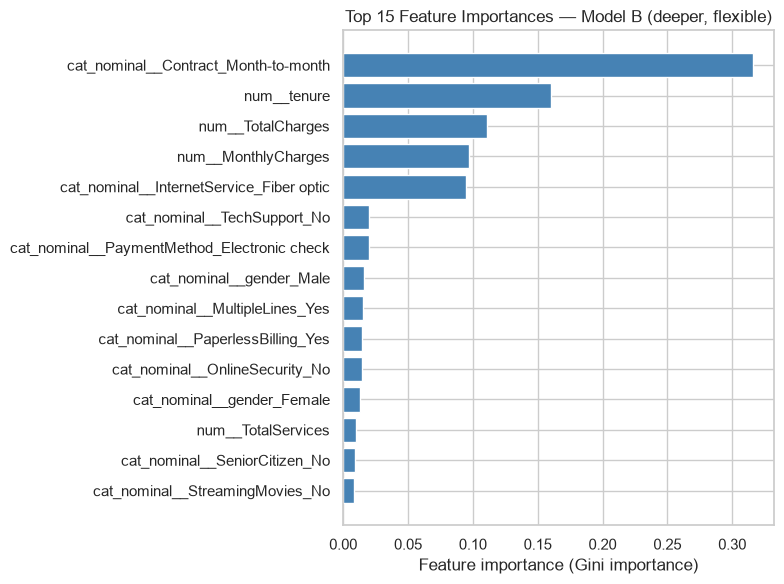

In [48]:
top_n = 15
top_features = feature_importance_df.head(top_n).iloc[::-1]  # reverse for a top-to-bottom barh chart

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_features["feature"], top_features["importance"], color="steelblue")
ax.set_xlabel("Feature importance (Gini importance)")
ax.set_title(f"Top {top_n} Feature Importances — {final_model_name}")
plt.tight_layout()
plt.show()

### 12.2 Top features: what they mean and why they matter

The top 5 features account for **~78% of total importance** (0.3164 + 0.1599 + 0.1112 + 0.0967 + 0.0948 = 0.7790); everything past rank 5 contributes less than 0.02 each:

1. **`Contract_Month-to-month` (0.3164)** — by far the single most important feature. This directly echoes the Section 6.2 EDA finding (month-to-month churn 42.7% vs. one-year 11.3% vs. two-year 2.8%): a contract with no lock-in period gives a customer an easy exit at any time, so the model leans on it heavily to separate likely churners from likely stayers.
2. **`tenure` (0.1599)** — how long the customer has been with the company. This lines up with Section 6.4's finding that churn rate declines steadily with tenure (47.4% in the 0-12 month bucket down to 6.6% at 61-72 months): newer customers haven't yet built loyalty, habits, or switching friction.
3. **`TotalCharges` (0.1112)** — cumulative amount billed to date. This is highly correlated with tenure (longer-tenured customers have naturally accumulated more charges), so part of its importance likely reflects the same "customer longevity" signal tenure already captures, seen from a different angle.
4. **`MonthlyCharges` (0.0967)** — matches Section 6.5's finding that churners have a higher median monthly bill ($79.65) than non-churners ($64.43); higher recurring cost gives a customer more incentive to shop around.
5. **`InternetService_Fiber optic` (0.0948)** — matches Section 6.3 (fiber-optic churn 41.9% vs. DSL 19.0% vs. none 7.4%). This may reflect fiber being priced at a premium, a more competitive fiber market, or service-quality complaints specific to fiber — the model can't distinguish which, it only sees that this indicator co-occurs with churn.

**What the telecom company could potentially do with this, based only on what the model shows:**
- Since month-to-month contract is the dominant driver, an incentive to move month-to-month customers onto one-year or two-year contracts (the two categories with dramatically lower churn in the EDA) is the most directly supported action.
- Since low tenure is the second-strongest driver, extra onboarding attention or early-tenure retention outreach in the first 12 months could target the highest-risk segment the model identifies.
- Since higher `MonthlyCharges` is associated with churn, reviewing pricing or offering loyalty discounts to high-bill customers on month-to-month plans is a data-supported (not invented) lever, since that combination is exactly what the model weighs most.
- Fiber-optic customers churning more is worth investigating operationally (service quality, competitor pricing) — the model flags the association but does not explain its cause.

These are only what the current feature importances directly support; anything beyond this (e.g. a specific discount amount, a specific onboarding program) would be a business decision outside the scope of what this model's results establish.

### 12.3 Limitations of Decision Tree feature importance

- **No direction of effect.** `feature_importances_` says `Contract_Month-to-month` matters a lot, but not *which way* — we only know it's directionally consistent with the Section 6.2 EDA (higher churn) because we cross-checked it manually. The importance score alone doesn't say "higher values increase churn."
- **Bias toward high-cardinality / continuous features.** Numeric features like `tenure`, `TotalCharges`, and `MonthlyCharges` have many possible split points, which structurally gives Gini importance more opportunities to find a useful split than a binary one-hot column has — so their importance can be somewhat inflated relative to categorical features, independent of true predictive power.
- **Correlated features split credit.** `tenure` and `TotalCharges` are highly correlated (both grow with customer age). The tree may arbitrarily pick one to split on at a given node, understating the other's importance even though they carry overlapping information — the true "customer longevity" signal may be larger than either feature's individual score suggests.
- **Instability.** A small change in the training data (a different random split, a few rows removed) can shift which correlated feature the tree happens to split on, changing the importance ranking without any real change in the underlying relationship. We saw the tree itself change meaningfully between Model A and Model B in Section 10, which is a symptom of this same instability.
- **No interaction detail.** Feature importance reports each feature's contribution in isolation; it doesn't tell us how `Contract_Month-to-month` and `InternetService_Fiber optic` interact together, even though the tree's actual splits may combine them.
- **Single-tree specific.** These importances come from one Decision Tree with one specific set of hyperparameters. A different `max_depth`/`min_samples_leaf` configuration (like Model A) could produce a different importance ranking, so these results describe *this particular fitted model*, not an absolute, model-independent ranking of what drives churn.

These limitations don't invalidate the top features identified above — the top 2-3 are corroborated independently by the Section 6 EDA — but they're a reason to treat the exact ordering and magnitudes as approximate rather than definitive.

### 12.4 Visualizing the tree itself

The final model was trained with `max_depth=10`, which would render as an unreadable wall of hundreds of nodes if plotted in full. Instead, `plot_tree` is used with `max_depth=3` — showing only the top 3 levels of decisions (root → 2 levels of splits), which is enough to see the tree's overall logic without the clutter. The full depth-10 tree still exists and is what actually generates predictions; this is a limited, readable *view* of it for interpretation purposes only.

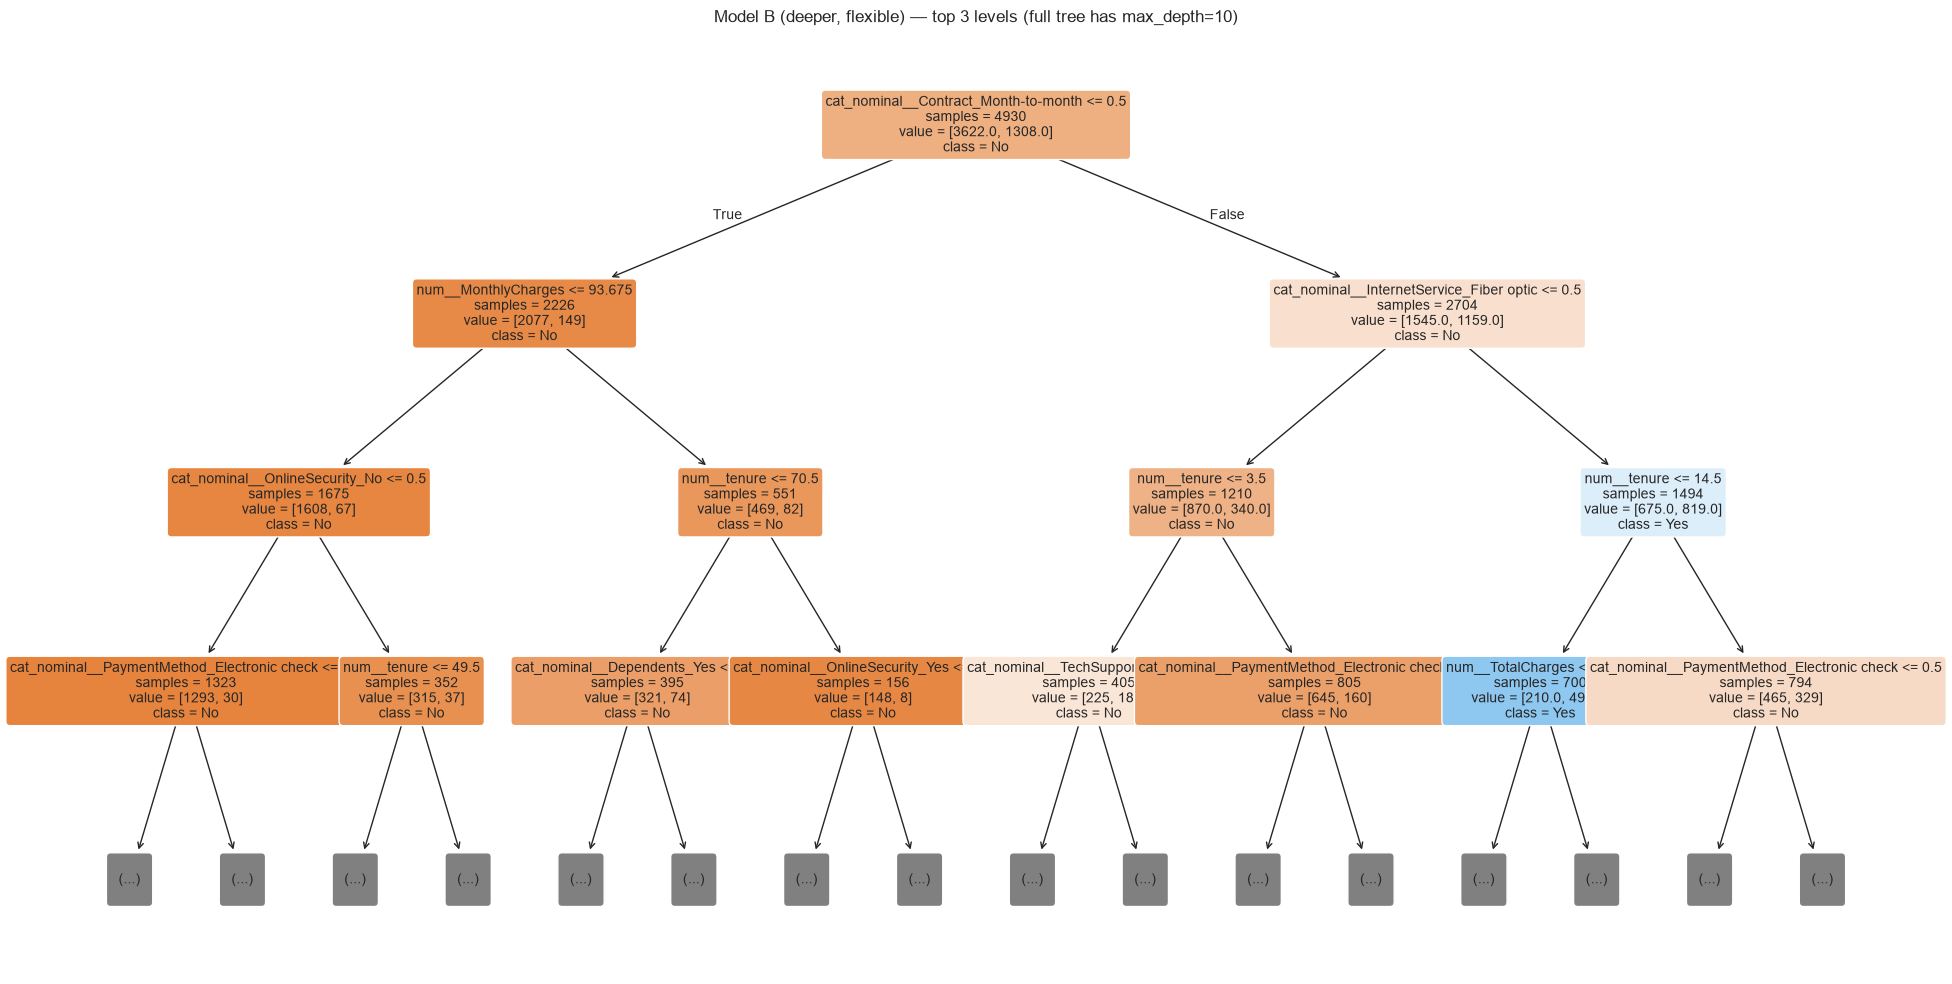

In [49]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    final_classifier,
    max_depth=3,
    feature_names=transformed_feature_names,
    class_names=final_classifier.classes_,
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=10,
    ax=ax,
)
ax.set_title(f"{final_model_name} — top 3 levels (full tree has max_depth=10)")
plt.tight_layout()
plt.show()

### 12.5 Reading the tree

**Root node (top box):** `cat_nominal__Contract_Month-to-month <= 0.5`, covering all 4,930 training customers, `value = [3622, 1308]` (No, Yes), majority class **No**. This confirms Section 12.2's finding that contract type is the single most important feature — it's the very first question the tree asks. Since this column is one-hot encoded (1 = has a month-to-month contract, 0 = doesn't), "`<= 0.5`" is really asking **"is this NOT a month-to-month contract?"**

**Decision splits:** every non-leaf box asks one yes/no question about one feature threshold. If the customer's value satisfies the condition, they follow the **True** arrow (left); otherwise the **False** arrow (right). For example, the root's True branch (not month-to-month: one-year/two-year contracts) has only 2,226 customers with a **6.7% churn rate** (149/2226); the False branch (month-to-month) has 2,704 customers with a **42.9% churn rate** (1,159/2,704) — matching Section 6.2's EDA almost exactly. On the month-to-month side, the next question is `InternetService_Fiber optic <= 0.5`: month-to-month customers **without** fiber (1,210 people) churn at 28.1%, while month-to-month customers **with** fiber (1,494 people) already tip into a **majority-churn leaf-in-progress** (819/1,494 = 54.8%, predicted class flips to **Yes**) — directly reflecting Section 6.3's fiber-optic finding.

**Leaf nodes:** the boxes at the bottom of a fully-drawn path (shown here as gray `(...)` triangles, since this view is cut off at depth 3 — the real tree continues for several more levels). A leaf has no more questions; every customer who lands there gets the same predicted class, based on whichever class is the majority among the training customers who ended up in that leaf.

**Predicted class:** shown by the `class = ...` label in every box (the majority class *if the tree stopped here*) and reinforced by color — orange shades mean majority **No**, blue shades mean majority **Yes**, and the darker/more saturated the color, the more one-sided (pure) that group is. Only one node above is blue (`InternetService_Fiber optic <= 0.5`'s False branch — month-to-month + fiber), showing it's the first point in the tree where churners already outnumber stayers.

**How a customer moves through the tree — worked example:** take a month-to-month, fiber-optic customer with 8 months of tenure. At the root, `Contract_Month-to-month = 1`, which is **not** `<= 0.5`, so they go **False → right** (the 2,704-customer, 42.9%-churn branch). Next, `InternetService_Fiber optic = 1`, again **not** `<= 0.5`, so **False → right** again, landing in the 1,494-customer, 54.8%-churn group. From there, the actual (deeper) tree would keep asking about `tenure`, `TotalCharges`, `PaymentMethod`, etc., narrowing this customer into smaller and smaller groups until they reach one specific leaf, whose majority class becomes the final prediction for that customer.

### 12.6 Why this helps communicate the model to a non-technical stakeholder

- **It mirrors how a person already reasons about the business.** "Month-to-month + fiber-optic + short tenure = high risk" is a sentence a call-center manager can say out loud — the tree's top few levels are literally that sentence, drawn as a flowchart.
- **No statistics background required.** A stakeholder doesn't need to know what Gini importance or `max_depth` mean to read "if X, then go this way; if not, go that way" and "orange = probably stays, blue = probably churns."
- **It's traceable to a specific customer.** Given any one real customer's details, anyone can walk the same True/False path by hand and see exactly why the model predicts what it predicts — this is much harder to do with the raw feature importance table from Section 12.2 alone.
- **It corroborates, rather than contradicts, the EDA.** Because the top splits (contract type, fiber optic, tenure) reproduce percentages the business team already saw in Section 6, this visualization builds trust that the model learned recognizable, sensible patterns rather than something opaque.
- **Limiting the depth keeps it honest, not misleading.** Showing only the top 3 levels (rather than force-fitting the full depth-10 tree into a tiny unreadable image) keeps the visualization legible while the accompanying text is explicit that deeper, more detailed splits exist and drive the final leaf-level predictions.

## Model Persistence: Saving the Final Pipeline

The final selected model (`final_model`, Model B — deeper, flexible) is the **entire fitted `Pipeline`** — preprocessing (`ColumnTransformer`) plus the `DecisionTreeClassifier` — not just the bare classifier. It is saved with `joblib` to `model/churn_model.pkl` so that a separate process (e.g. the Day 2 FastAPI service) can load it and score raw, unprocessed customer records directly.

In [50]:
import joblib

# Reuse MODEL_DIR resolved in Section 2 - guarantees this always saves to the project's real
# model/ folder, regardless of the working directory the kernel started in.
MODEL_DIR.mkdir(exist_ok=True)
model_path = MODEL_DIR / "churn_model.pkl"

# final_model is the complete fitted Pipeline: ColumnTransformer (preprocessing) + DecisionTreeClassifier (Model B)
joblib.dump(final_model, model_path)

print(f"Saved pipeline to: {model_path}")
print(f"File size: {model_path.stat().st_size / 1024:.1f} KB")
print(f"Pipeline steps: {list(final_model.named_steps.keys())}")

Saved pipeline to: /Users/khushbookochhar/telco-customer-churn/model/churn_model.pkl
File size: 54.3 KB
Pipeline steps: ['preprocessor', 'classifier']


In [51]:
# 1. Load the saved pipeline from disk (simulates a separate process, e.g. the Day 2 API, starting fresh)
loaded_model = joblib.load(model_path)

# 2. Create one sample customer record using raw input fields (same shape of data the API would receive)
sample_customer_raw = {
    "gender": "Male", "SeniorCitizen": "No", "Partner": "No", "Dependents": "No",
    "tenure": 5, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes", "StreamingMovies": "Yes",
    "Contract": "Month-to-month", "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.20, "TotalCharges": 476.00,
}

# Apply the same shared feature engineering (src/feature_engineering.py) used on the training
# data, so the record has the engineered TotalServices/tenure_group columns the pipeline's
# preprocessor expects. This is the same function the Day 2 API will call.
sample_customer_df = engineer_features(pd.DataFrame([sample_customer_raw]))[X_train.columns]  # match training column order

# 3. Pass it through the loaded pipeline (preprocessing + Decision Tree, all in one object)
# 4. Generate a prediction
sample_prediction = loaded_model.predict(sample_customer_df)[0]

# 5. Generate churn probability
sample_proba = loaded_model.predict_proba(sample_customer_df)[0]
proba_by_class = dict(zip(loaded_model.named_steps["classifier"].classes_, sample_proba))

print("Sample customer (engineered fields):", sample_customer_df[["TotalServices", "tenure_group"]].iloc[0].to_dict())
print(f"\nPredicted class: {sample_prediction}")
print(f"Predicted probabilities: {proba_by_class}")
assert sample_prediction in loaded_model.named_steps["classifier"].classes_
assert abs(sum(sample_proba) - 1.0) < 1e-6
print("\nValid prediction confirmed: predicted class is one of the trained classes, and probabilities sum to 1.")

Sample customer (engineered fields): {'TotalServices': 4, 'tenure_group': '0-12'}

Predicted class: Yes
Predicted probabilities: {'No': np.float64(0.07692307692307693), 'Yes': np.float64(0.9230769230769231)}

Valid prediction confirmed: predicted class is one of the trained classes, and probabilities sum to 1.


**Verified:** the loaded pipeline predicted **Yes** (churn) for the sample customer — a month-to-month, fiber-optic customer with only 5 months of tenure and no protective add-ons — with **92.3% predicted probability of churn**. The predicted class is one of the two trained classes and the probabilities sum to 1, confirming the round-tripped (saved → loaded) pipeline behaves identically to `final_model` in memory.

### Why save the entire pipeline instead of just the Decision Tree

- **The classifier alone cannot read raw data.** `DecisionTreeClassifier.predict()` requires a numeric matrix (here, 48 columns of imputed/encoded values). Raw fields like `Contract="Month-to-month"` or `InternetService="Fiber optic"` mean nothing to it directly — the `ColumnTransformer` (imputation, one-hot encoding, ordinal encoding) is what turns raw fields into that matrix, and this exact transformation must happen identically every time.
- **Preventing train/serve skew.** If the preprocessing logic were reimplemented separately in the API instead of reusing the fitted `ColumnTransformer`, any small difference (a different imputation value, a missed category, a different column order) would silently produce different inputs to the tree than it was trained on — degrading or invalidating its predictions without any obvious error. Saving the fitted pipeline as one object guarantees the exact fitted imputers/encoders (with their learned statistics, like median `TotalCharges` or the fitted one-hot categories) travel with the model.
- **One artifact, one load call.** `joblib.load("model/churn_model.pkl")` returns something immediately usable with `.predict()`/`.predict_proba()` on a raw customer record — no need to separately ship and synchronize the preprocessor, its fitted parameters, and the classifier as three things that must always stay in version-lockstep.
- **This is exactly what Section 9.5 already established** about `ColumnTransformer`/`Pipeline` preventing leakage and enabling reuse on unseen data — saving the whole pipeline is simply persisting that same reusable object to disk so a different process (the Day 2 FastAPI service) can load and reuse it without having access to `X_train`, `preprocessor`, or any of this notebook's in-memory state.

## 13. Final Findings

Summarize key findings end-to-end: main churn drivers, chosen model and why, evaluation results and their business implications, and next steps (saving the pipeline for reuse by the Day 2 API).

**Why this section is required:** the assignment expects the notebook to demonstrate the complete workflow from business problem through to interpretation — this closing summary ties the narrative together for a reviewer.